# Projet: Analyse des données et pre-processing

Eduardo Cobos Fernandez, Sipan Bareyan Jeremy Rakotorinira, Amine Berrahma

Analyse et réduction des bias en Machine Learning

# 0 - Introduction

Ce projet s'inscrit dans le cadre de l'analyse et la réduction des biais en Machine Learning appliqué au domaine médical. Les modèles de prédiction utilisés en imagerie médicale peuvent hériter des biais présents dans les données d'entraînement, conduisant à des performances inéquitables selon certains groupes de patients.

IL s’appuie sur le dataset Chest X-ray NIH14 (https://www.kaggle.com/datasets/nih-chest-xrays/data), qui contient des radiographies thoraciques ainsi que des métadonnées associées aux patients, telles que l’âge, le genre et les pathologies diagnostiquées. L'objectif est de classifier chaque radiographie comme saine ou malade, tout en garantissant l'équité du modèle vis-à-vis des attributs sensibles.

Ce notebook est structuré en trois parties :

- **Analyse des données** : analyse univariée, bivariée et multivariée des métadonnées afin d'identifier les déséquilibres et biais présents dans le dataset

- **Pre-processing** : application de la méthode de Reweighting sur les attributs sensibles genre et âge, suivi de l'entraînement d'un modèle ResNet18 et de l'évaluation de son impact sur les performances et les métriques d'équité.

- **Post-processing** : correction des prédictions du modèle entraîné via deux méthodes (Reject-Option Classification et Calibrated Equalized Odds), ainsi que l'étude des combinaisons pre + post-processing.

# Chargement des données

Les métadonnées du dataset Chest X-ray NIH14 sont chargées à partir du fichier fourni pour le projet. Ce fichier contient les informations associées à un sous-ensemble de 6 000.

In [4]:
from pathlib import Path

DATADIR= Path('Cobos_Fernandez_Eduardo')

In [ ]:
### RUN ONLY ON COLAB: Put the zip file of the data in your google drive in a folder called "fairness"
confirm = input("Are you sure you are running this on Colab ? Confirm with 'y'")
if confirm != 'y':
    raise ValueError("You must confirm you are running on Colab")
# Only for Google Colab
from google.colab import drive
drive.mount('/content/drive')


# Only for Google Colab
import sys

# In your google drive, create a folder for the Fairness project
# (called here 'coursFairness')
# Copy in this folder the python file train_classifieur.py
# Copy in this folder your zipped data folder (called here 'YOUR_NAME.zip')

# Path to the folder containing the python file
drive_module_path = "drive/MyDrive/fairness" #modifié pour que ça marche sur ma machine
sys.path.append(drive_module_path)

# Verify the path was added
print(sys.path[-1])

project_folder = Path(drive_module_path)
zip_filename = "Cobos_Fernandez_Eduardo.zip"
zip_path = project_folder / zip_filename

if not project_folder.exists() or not zip_path.exists():
  print("Colab Config failed")
  print("Make sure you have the folder fairness folder in your google drive, and it contains the zip file named Cobos_Fernandez_Eduardo.zip")
  raise ValueError("Colab Config failed")


!cp /content/drive/MyDrive/fairness/Cobos_Fernandez_Eduardo.zip /content/
!mkdir -p /content/DATA/
!unzip -o Cobos_Fernandez_Eduardo.zip -d /content/DATA/

!pip install pandas\
  numpy\
  torchvision\
  torch\
  torchmetrics\
  tensorboard\
  pillow\
  lightning\
  matplotlib\
  scikit_learn\
  ipykernel \
  fairlearn \
  plotly \
  nbformat \
  aif360["inFairness"] \
  aif360['AdversarialDebiasing'] \
  causal-learn \
  BlackBoxAuditing \
  cvxpy \
  dice-ml \
  lime \

DATADIR = Path("/content/DATA")


In [5]:
import pandas as pd
import numpy as np
import plotly.express as px
from aif360.sklearn.metrics import *

import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from IPython.display import display

from scipy.stats import chi2_contingency


#from train_classifieur import train_classifier, pred_classifier

/Users/eduardo/Desktop/Cours/L3/Fairness/Projet/.venv/lib/python3.13/site-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/Users/eduardo/Desktop/Cours/L3/Fairness/Projet/.venv/lib/python3.13/site-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/d

In [6]:
# On commence par charger les donnees depuis le csv
df = pd.read_csv(DATADIR/'metadata.csv')      #j'ai chargé mes données, il faudra decider lequels utiliser

# On peut regarder les premieres lignes du dataset
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,train_valid,label,WEIGHTS
0,00000011_000.png,Effusion,0,11,75,M,PA,2638,2449,0.143,0.143,NaN,train,malade,1
1,00000011_001.png,No Finding,1,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
2,00000011_002.png,No Finding,2,11,75,M,PA,2714,2781,0.143,0.143,NaN,train,sain,1
3,00000011_003.png,No Finding,3,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1
4,00000011_004.png,No Finding,4,11,75,M,PA,2500,2048,0.168,0.168,NaN,train,sain,1


# 1 - Préparation des données :

Dans cette partie, une analyse est réalisée afin d’observer les dimensions du dataset, les types de variables ainsi que leur distribution. Une attention particulière est portée à la détection de valeurs aberrantes, notamment sur la variable âge, afin de garantir la cohérence des informations.

Enfin, certaines transformations sont effectuées pour faciliter l’analyse, notamment la création d’une variable binaire indiquant la présence ou l’absence de maladie, ainsi que la catégorisation de l’âge en groupes. Ces étapes permettent d’obtenir un dataset propre, structuré et adapté à l’analyse des biais

# Informations sur le Dataset

In [7]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5593 entries, 0 to 5592
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Image Index                  5593 non-null   object 
 1   Finding Labels               5593 non-null   object 
 2   Follow-up #                  5593 non-null   int64  
 3   Patient ID                   5593 non-null   int64  
 4   Patient Age                  5593 non-null   int64  
 5   Patient Gender               5593 non-null   object 
 6   View Position                5593 non-null   object 
 7   OriginalImage[Width          5593 non-null   int64  
 8   Height]                      5593 non-null   int64  
 9   OriginalImagePixelSpacing[x  5593 non-null   float64
 10  y]                           5593 non-null   float64
 11  Unnamed: 11                  0 non-null      float64
 12  train_valid                  5593 non-null   object 
 13  label             

On observe que le dataset contient 5593 observations de patients et 14 variables.
Ces variables sont composées d'informations démographiques (age, genre), d'informations techniques (position de vue, taille de l'image originelle, le spacing des pixels) ainsi que le nombre de visites effectués préalablement et si le patient il est malade ou sain (Finding Labels contient les maladies identifiés si il en a). Cette dernière infomartion sera notre label car l'objectif est de prédire si le patient est malade ou pas. Additionelement, on a comme information si l'image a été utilisée dans le train set ou le validation set et le poids avec lequel elle va être utilisée dans l'entrainement de notre modèle.

## Data Cleaning

Tout d'abord on a vu avec df.info() qu'il n'y a pas de valeurs nulles dans notre dataset sauf pour la colonne 'Unnamed: 11' qui est une erreur et tous les types des données sont bien placés. Pas besoin de traiter nos données pour ceci.


On remarque que les informations OriginalImage[Width, Height] et OriginalImagePixelSpacing[x y] données par les colonnes 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]' n'apportent aucune information intéressante. De même pour la colonne Unnamed: 11 qui c'est probablement glissée dans les métadonnées par erreur. On peut donc procéder à les supprimer.

In [8]:
df = df.drop(columns=['OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]', 'Unnamed: 11'])

In [9]:
df

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,train_valid,label,WEIGHTS
0,00000011_000.png,Effusion,0,11,75,M,PA,train,malade,1
1,00000011_001.png,No Finding,1,11,75,M,PA,train,sain,1
2,00000011_002.png,No Finding,2,11,75,M,PA,train,sain,1
3,00000011_003.png,No Finding,3,11,75,M,PA,train,sain,1
4,00000011_004.png,No Finding,4,11,75,M,PA,train,sain,1
...,...,...,...,...,...,...,...,...,...,...
5588,00030772_001.png,Consolidation,1,30772,26,F,AP,train,malade,1
5589,00030772_002.png,Consolidation,2,30772,26,F,AP,train,malade,1
5590,00030774_000.png,Consolidation,0,30774,44,F,PA,valid,malade,1
5591,00030784_000.png,No Finding,0,30784,25,F,PA,train,sain,1


À partir de ce que l'on a trouvé lors du mi-projet on peut faire le nettoyage de nos données rapidement. On regarde qu'il n'y ai pas d'index répétés, que les valeurs numériques soient cohérentes, que les valeurs de type object fassent partie des valeurs possibles.

In [10]:
if not (df['Image Index'].is_unique):
    print("Les index ne sont pas individuels")
if ((df["Follow-up #"] < 0).any()):
    print("Il y a des Follow-up négatifs")
if ((df["Patient Age"] < 0).any()):
    print("Il y a des âges négatifs")
if ((df["Patient Age"] > 110).any()):
    print("Il y a des âges plus grands que 110")
if (set(df["Patient Gender"]) != {'F', 'M'}):
    print("Le patient gender prend des valeures différentes de \"M\" ou \"F\"")
if (set(df["View Position"]) != {'AP', 'PA'}):
    print("Le view position prend des valeures différentes de \"AP\" ou \"PA\"")
if (set(df["train_valid"]) != {'train', 'valid'}):
    print("La colonne train_valid prend des valeures différentes de \"train\" ou \"valid\"")
if (set(df["label"]) != {'malade', 'sain'}):
    print("La colonne label prend des valeures différentes de \"malade\" ou \"sain\"")

Il y a des âges plus grands que 110


Le seul nettoyage à faire et donc sur les âges. On observe des âges supérieurs à 110 et biologiquement improbables. On les supprime directement car quelques valeurs dans un si grand dataset sont négligeables.

In [11]:
df = df[df["Patient Age"] <= 110]

## Transformation des colonnes

Pour l'analyse descriptive des données on va procéder à faire un multi one-hot encoding sur la colonne finding labels en créant une colonne par maladie.
De plus, afin de simplifier la lecture des données âge et pouvoir les utiliser dans le préprocessing on va la transformer en une donnée catégorielle en créant des tranches d'âges.

In [12]:
# on crée les tranches d'âge
df["Age_Group"] = pd.cut(
    df["Patient Age"],
    bins=[0, 20, 40, 60, 80, 120],
    labels=["0-20", "20-40", "40-60", "60-80", "80+"],
    right=False
)
# on ne supprime pas la colonne avec les âges exacts au cas ou on devrais en vaoir besoin après mais en principe il n'y a pas besoin

/var/folders/2s/g233_y4543g3nv84_mqys8bc0000gp/T/ipykernel_3259/3754337491.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Age_Group"] = pd.cut(


In [13]:
# on crée les tranches de follow ups pour faciliter la visualisation
df["Follow-up_Group"] = pd.cut(
    df["Follow-up #"],
    bins=[0, 5, 10, 15, 25, 50, 500],
    labels=["0-5", "5-10", "10-15", "15-25", "25-50", "50+"],
    right=False
)
# on ne supprime pas la colonne avec les âges exacts au cas ou on devrais en vaoir besoin après mais en principe il n'y a pas besoin

/var/folders/2s/g233_y4543g3nv84_mqys8bc0000gp/T/ipykernel_3259/2379387146.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Follow-up_Group"] = pd.cut(


In [14]:
# on fait le one_hot sur les phatologies
dummies = df["Finding Labels"].str.get_dummies(sep="|")

df_one_hot = pd.concat([df, dummies], axis=1)
df_one_hot = df_one_hot.drop(columns=["Finding Labels"])

In [49]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,train_valid,label,WEIGHTS,Age_Group,Follow-up_Group
0,00000011_000.png,Effusion,0,11,75,M,PA,train,malade,1,60-80,0-5
1,00000011_001.png,No Finding,1,11,75,M,PA,train,sain,1,60-80,0-5
2,00000011_002.png,No Finding,2,11,75,M,PA,train,sain,1,60-80,0-5
3,00000011_003.png,No Finding,3,11,75,M,PA,train,sain,1,60-80,0-5
4,00000011_004.png,No Finding,4,11,75,M,PA,train,sain,1,60-80,0-5


Maintenant on a deux tableaux, l'un avec les maladies codées en one-hot pour l'analyse et un sans le one-hot pour l'entrainement du modèle

## Analyse des données

Dans cette partie, on va réaliser une analyse univariée afin de comprendre la distribution individuelle des variables clés, telles que le genre, l’âge et le statut de maladie.

Avec une analyse bivariée on va ensuite examiner la relation entre les attributs sensibles (genre et groupes d’âge) et le label, afin de détecter d’éventuelles disparités.

Enfin, on va réaliser une analyse multivariée qui approfondi l’étude en combinant plusieurs variables, suivie du calcul de métriques d’équité telles que le Statistical Parity Difference et le Disparate Impact, ce qui permet de quantifier les biais potentiels présents dans les données.

### A) Analyse univarié

On va regarder les données importantes une par une et les anlyser.

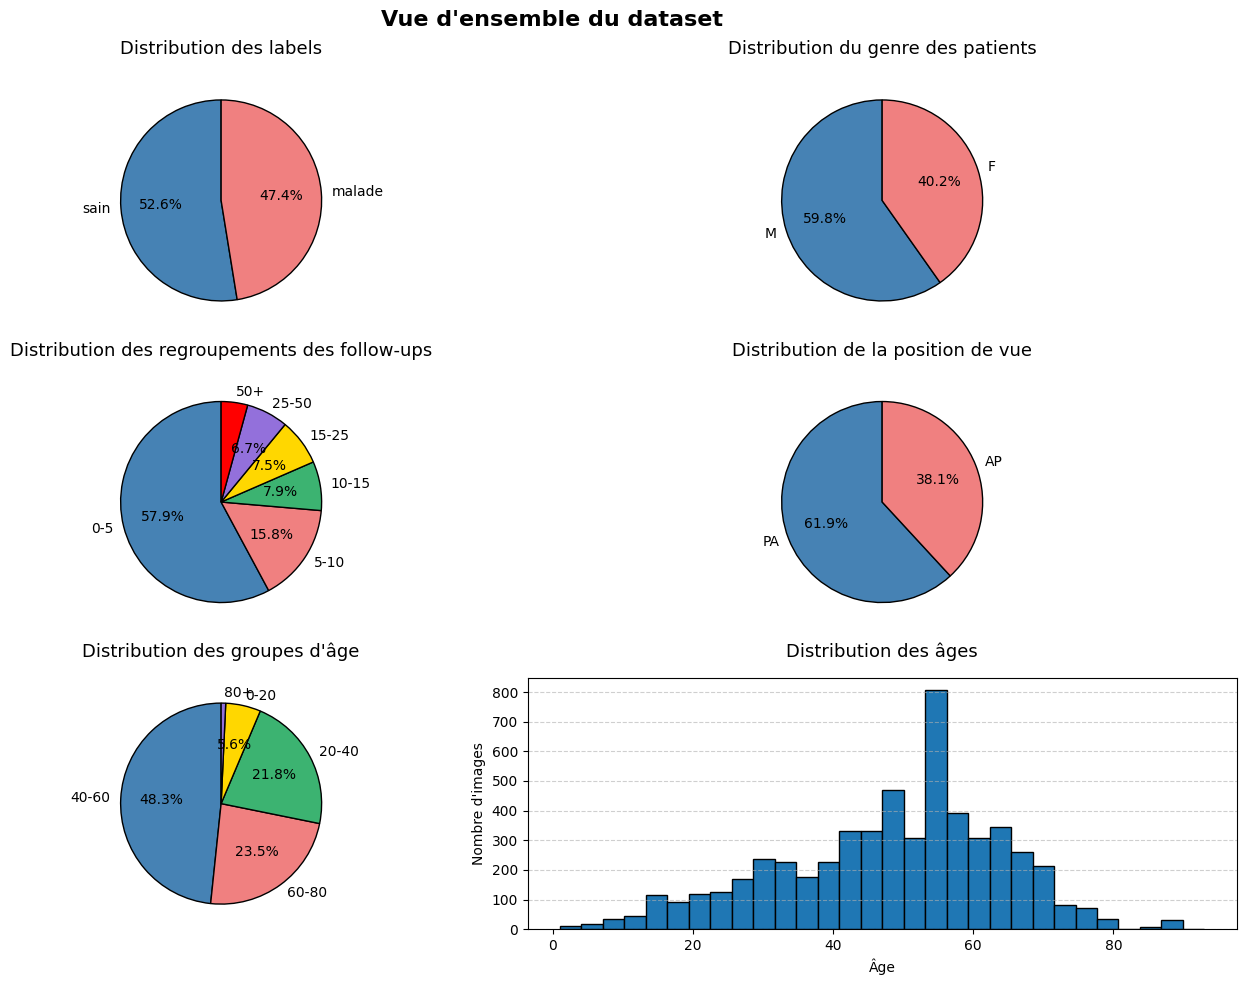

In [16]:
counts = [["label", "Patient Gender"], ["Follow-up_Group", "View Position"], ["Age_Group", "Patient Age"]]
titre = [["des labels", "du genre des patients"], ["des regroupements des follow-ups", "de la position de vue"], ["des groupes d'âge", "des âges"]]

fig, axes = plt.subplots(3, 2, figsize=(14,10))

for i in range(3):
    for j in range(2):
        if(i == 2 and j == 1):
            axes[i][j].hist(df[counts[i][j]], bins=30, edgecolor="black")
            axes[i][j].set_xlabel("Âge")
            axes[i][j].set_ylabel("Nombre d'images")
            axes[i][j].grid(axis="y", linestyle="--", alpha=0.6)
        else:
            axes[i][j].pie(
                df[counts[i][j]].value_counts(),
                labels = df[counts[i][j]].value_counts().index,
                autopct=lambda pct: f"{pct:.1f}%" if pct > 5 else "",
                startangle = 90,
                colors = ["steelblue", "lightcoral", "mediumseagreen", "gold", "mediumpurple", "red"] if ((i == 2 and j == 0) or (i == 1 and j == 0)) else ["steelblue", "lightcoral"],
                wedgeprops={"edgecolor": "black"},
            )

        axes[i][j].set_title(f"Distribution {titre[i][j]}", fontsize=13, pad=15)

fig.suptitle("Vue d'ensemble du dataset", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

L'analyse univariée révèle plusieurs caractéristiques importantes de notre dataset. On constate d'abord un léger déséquilibre de genre, avec 57% d'hommes contre 43% de femmes un écart notable sans être extrême, mais qu'il faudra surveiller dans l'analyse des biais. Côté label, la répartition entre patients sains et malades montre est de 52.6% contre 47.4%, ce qui ne constitue pas un déséquilibre significatif pour l'entraînement d'un modèle.
La distribution des âges se concentre principalement sur les tranches 40-60 et 60-80, avec une sous-représentation marquée des très jeunes (0-20) et des très âgés (80+). Cette asymétrie signifie que le modèle aura peu d'exemples pour ces groupes extrêmes, ce qui pourrait affecter ses performances sur ces populations. La position de vue est dominée par le PA, et les follow-ups se concentrent massivement dans la tranche 0-5, montrant que la majorité des patients n'ont que peu de visites enregistrées.

### B) Analyse bivariée

On va maintenant mettre en relation les données deux à deux et les analyser ainsi.

On commence avec les analyse bivariées vont avec le label

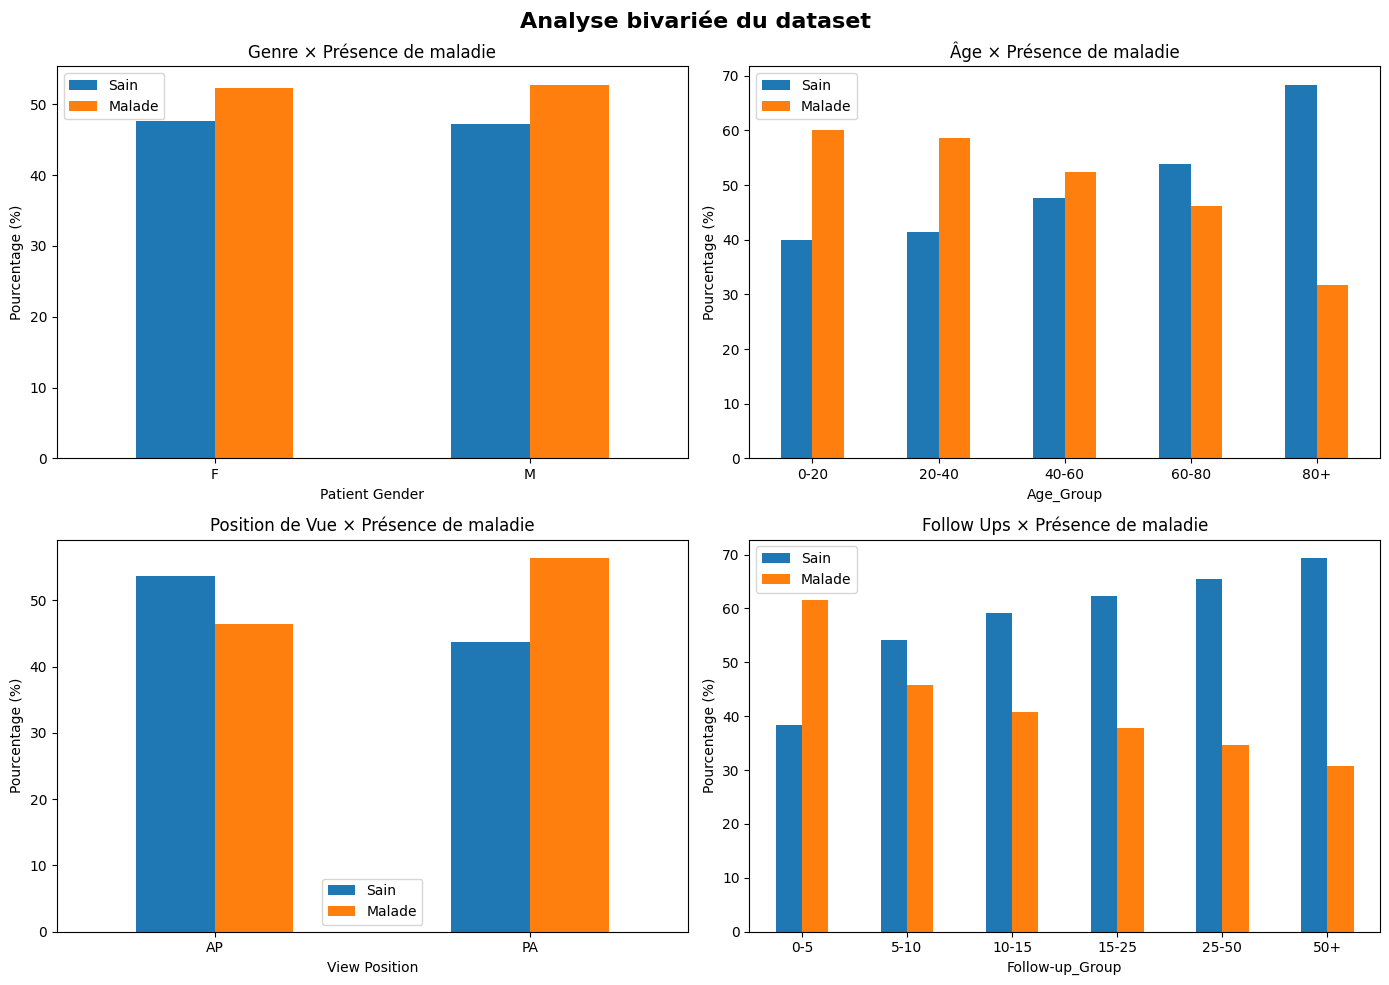

In [ ]:
#Genre × Maladie
table_genre_maladie = pd.crosstab(
    df["Patient Gender"],
    df["label"],
    normalize="index"
) * 100

#Age_group × Maladie
table_age_maladie = pd.crosstab(
    df["Age_Group"],
    df["label"],
    normalize="index"
) * 100

#View Position × Maladie
table_View_maladie = pd.crosstab(
    df["View Position"],
    df["label"],
    normalize="index"
) * 100

#Follow ups × Maladie
table_Follow_maladie = pd.crosstab(
    df["Follow-up_Group"],
    df["label"],
    normalize="index"
) * 100

counts = [[table_genre_maladie, table_age_maladie], [table_View_maladie, table_Follow_maladie]]
titre = [["Genre × Présence de maladie", "Âge × Présence de maladie"], ["Position de Vue × Présence de maladie", "Follow Ups × Présence de maladie"]]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for i in range(2):
    for j in range(2):
        counts[i][j].plot(kind="bar", ax=axes[i][j])
        axes[i][j].set_ylabel("Pourcentage (%)")
        axes[i][j].tick_params(axis='x', rotation=0)
        axes[i][j].legend(["Sain", "Malade"])

        axes[i][j].set_title(titre[i][j])

fig.suptitle("Analyse bivariée du dataset", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()



In [18]:
## analyse détaillée des résultats

#Genre × Maladie
diff_genre = table_genre_maladie.loc["M", "malade"] - table_genre_maladie.loc["F", "malade"]
rr_genre   = table_genre_maladie.loc["M", "malade"] / table_genre_maladie.loc["F", "malade"]
chi2, p_genre, _, _ = chi2_contingency(pd.crosstab(df["Patient Gender"], df["label"]))


print(f"  Taux malade Hommes : {table_genre_maladie.loc['M', 'malade']:.1f}%")
print(f"  Taux malade Femmes : {table_genre_maladie.loc['F', 'malade']:.1f}%")
print(f"  Différence H-F     : {diff_genre:+.2f}%")
print(f"  Risk Ratio (H/F)   : {rr_genre:.3f}")
print(f"  p-value            : {p_genre:.4f}")

#Age_group × Maladie , on prend comme référence le groupe 40-60 car c'est le plus représenté et le plus stable
diff_age = table_age_maladie["malade"] - table_age_maladie["malade"]["40-60"]
rr_age   = table_age_maladie["malade"] / table_age_maladie["malade"]["40-60"]
chi2, p_age, _, _ = chi2_contingency(pd.crosstab(df["Age_Group"], df["label"]))

print("\n")
print(f"  {'Groupe':<10} {'Taux malade':>12} {'Différence':>12} {'Risk Ratio':>12}")
for groupe in table_age_maladie.index:
    print(f"  {str(groupe):<10} {table_age_maladie.loc[groupe, 'malade']:>11.1f}%"
          f" {diff_age[groupe]:>+11.2f}%"
          f" {rr_age[groupe]:>12.3f}")
print(f"  p-value  : {p_age:.4f}")

#View Position × Maladie
diff_view = table_View_maladie.loc["AP", "malade"] - table_View_maladie.loc["PA", "malade"]
rr_view   = table_View_maladie.loc["AP", "malade"] / table_View_maladie.loc["PA", "malade"]
chi2, p_view, _, _ = chi2_contingency(pd.crosstab(df["View Position"], df["label"]))

print("\n")
print(f"  Taux malade AP   : {table_View_maladie.loc['AP', 'malade']:.1f}%")
print(f"  Taux malade PA   : {table_View_maladie.loc['PA', 'malade']:.1f}%")
print(f"  Différence AP-PA : {diff_view:+.2f}%")
print(f"  Risk Ratio(AP/PA): {rr_view:.3f}")
print(f"  p-value          : {p_view:.4f}")

#Follow ups × Maladie , on prend comme référence le groupe 0-5 car c'est le plus représenté et le plus stable
diff_follow = table_Follow_maladie["malade"] - table_Follow_maladie["malade"]["0-5"]
rr_follow   = table_Follow_maladie["malade"] / table_Follow_maladie["malade"]["0-5"]
chi2, p_follow, _, _ = chi2_contingency(pd.crosstab(df["Follow-up_Group"], df["label"]))

print("\n")
print(f"  {'Groupe':<10} {'Taux malade':>12} {'Différence':>12} {'Risk Ratio':>12}")
for groupe in table_Follow_maladie.index:
    print(f"  {str(groupe):<10} {table_Follow_maladie.loc[groupe, 'malade']:>11.1f}%"
          f" {diff_follow[groupe]:>+11.2f}%"
          f" {rr_follow[groupe]:>12.3f}")
print(f"  p-value : {p_follow:.4f}")

  Taux malade Hommes : 47.3%
  Taux malade Femmes : 47.7%
  Différence H-F     : -0.45%
  Risk Ratio (H/F)   : 0.991
  p-value            : 0.7634


  Groupe      Taux malade   Différence   Risk Ratio
  0-20              40.0%       -7.58%        0.841
  20-40             41.5%       -6.10%        0.872
  40-60             47.6%       +0.00%        1.000
  60-80             53.8%       +6.27%        1.132
  80+               68.3%      +20.72%        1.435
  p-value  : 0.0000


  Taux malade AP   : 53.6%
  Taux malade PA   : 43.7%
  Différence AP-PA : +9.93%
  Risk Ratio(AP/PA): 1.228
  p-value          : 0.0000


  Groupe      Taux malade   Différence   Risk Ratio
  0-5               38.4%       +0.00%        1.000
  5-10              54.1%      +15.74%        1.410
  10-15             59.2%      +20.79%        1.542
  15-25             62.3%      +23.90%        1.622
  25-50             65.4%      +27.03%        1.704
  50+               69.3%      +30.94%        1.806
  p-value : 0.

On peut procéder à analyser ces résultats:

Genre × Maladie : la p-value est > 0.05. Le biais n'est donc pas significatif et on en tire que le genre n'est pratiquement pas lié à la présence de maladie dans ce dataset.

Age_group × Maladie : la p-value est < 0.05. Le biais est donc significatif. Le groupe d'âge a un biais fort sur le label. Dans le dataset, plus le patient est âgé plus il est susceptible d'être malade et les jeunes sont sous représentés parmis les malades.

View Position × Maladie : la p-value est < 0.05. Le biais est donc significatif. Le position de vue a un biais fort sur le label. C'est lié aux conditions dans lesquelles la postion de vue est décidée mais si un groupe démographique est sur-réprésenté dans une position de vue le modèle pourrait faire des associations biaisées via la position de vue.

Follow ups × Maladie : la p-value est < 0.05. Le biais est donc significatif. Le nombre ded follow-ups d'un patient a un biais fort sur le label. Plus un patient a eu de visites, plus il est malade. Cependant Follow-Up n'est pas vraiment un attribut sensible comme l'âge ou le genre, c'est plutôt une conséquence de la maladie. Il est donc moins pertinent pour l'analyse de biais.

On va maintenant faire l'analyse bivariée entre autres classes sans prendre le label:

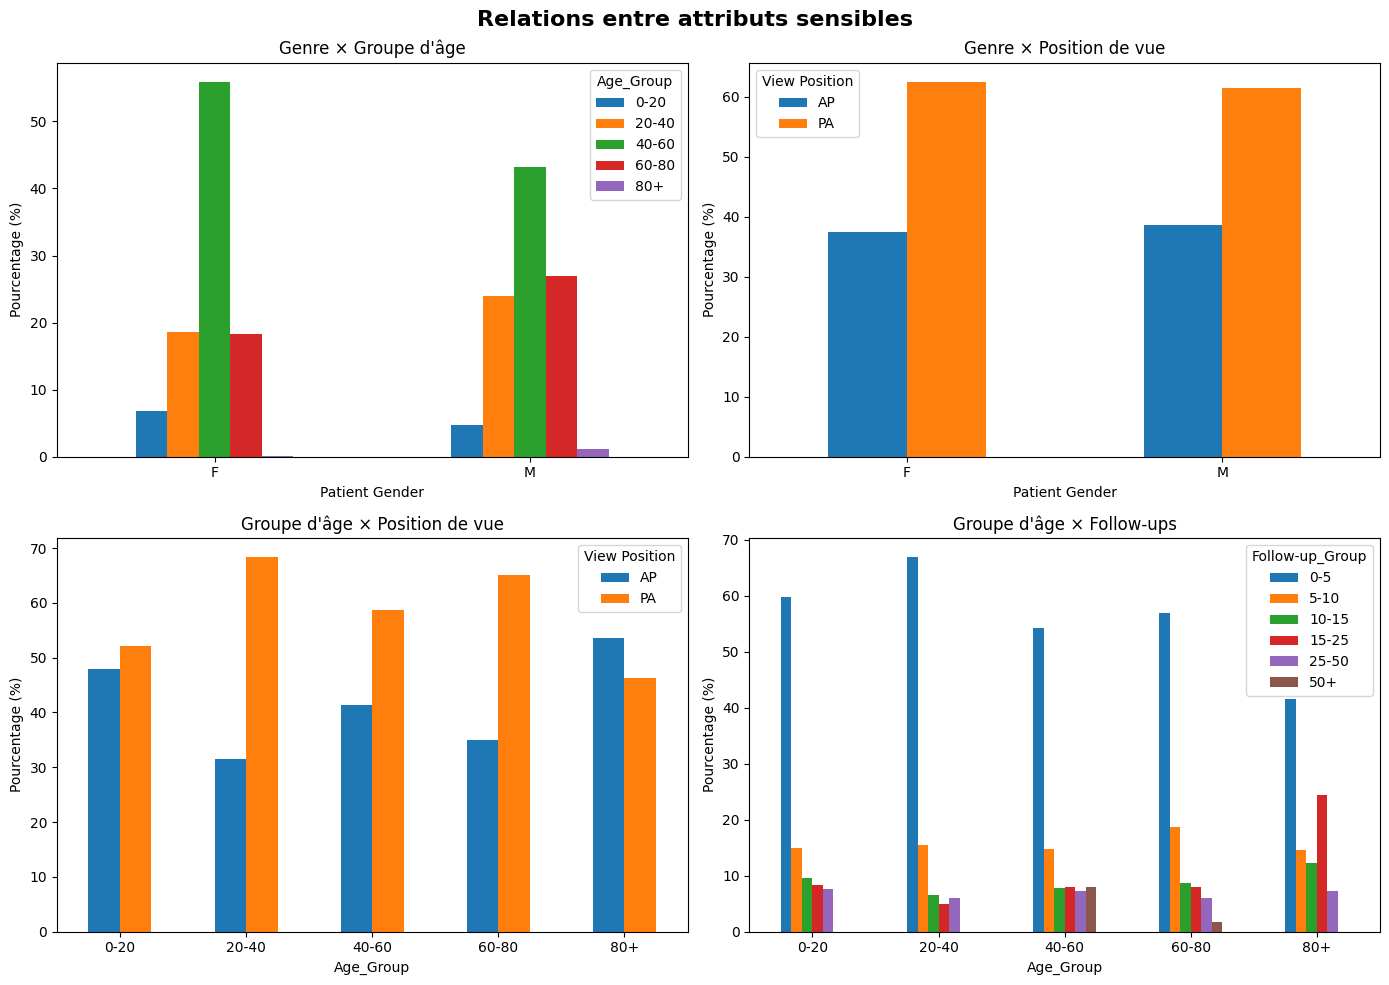

In [19]:
# Genre × Age_Group
table_genre_age = pd.crosstab(
    df["Patient Gender"],
    df["Age_Group"],
    normalize="index"
) * 100

# Genre × View Position
table_genre_view = pd.crosstab(
    df["Patient Gender"],
    df["View Position"],
    normalize="index"
) * 100

# Age_Group × View Position
table_age_view = pd.crosstab(
    df["Age_Group"],
    df["View Position"],
    normalize="index"
) * 100

# Age_Group × Follow-up_Group
table_age_follow = pd.crosstab(
    df["Age_Group"],
    df["Follow-up_Group"],
    normalize="index"
) * 100

tables = [[table_genre_age, table_genre_view],
          [table_age_view,  table_age_follow]]

titres = [["Genre × Groupe d'âge",       "Genre × Position de vue"],
          ["Groupe d'âge × Position de vue", "Groupe d'âge × Follow-ups"]]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

for i in range(2):
    for j in range(2):
        tables[i][j].plot(kind="bar", ax=axes[i][j])
        axes[i][j].set_ylabel("Pourcentage (%)")
        axes[i][j].tick_params(axis='x', rotation=0)
        axes[i][j].legend(title=tables[i][j].columns.name)
        axes[i][j].set_title(titres[i][j])

fig.suptitle("Relations entre attributs sensibles", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
## Analyse statistique — relations entre attributs sensibles

# Genre × Age_Group
chi2, p_genre_age, _, _ = chi2_contingency(pd.crosstab(df["Patient Gender"], df["Age_Group"]))

print(f"  {'Groupe d\'âge':<10} {'% Hommes':>10} {'% Femmes':>10} {'Différence':>12}")
for groupe in table_genre_age.columns:
    diff = table_genre_age.loc["M", groupe] - table_genre_age.loc["F", groupe]
    print(f"  {str(groupe):<10} {table_genre_age.loc['M', groupe]:>9.1f}%"
          f" {table_genre_age.loc['F', groupe]:>9.1f}%"
          f" {diff:>+11.2f}%")
print(f"  p-value : {p_genre_age:.4f}")

# Genre × View Position
diff_genre_view = table_genre_view.loc["M", "AP"] - table_genre_view.loc["F", "AP"]
rr_genre_view   = table_genre_view.loc["M", "AP"] / table_genre_view.loc["F", "AP"]
chi2, p_genre_view, _, _ = chi2_contingency(pd.crosstab(df["Patient Gender"], df["View Position"]))

print("\n")
print(f"  % AP Hommes        : {table_genre_view.loc['M', 'AP']:.1f}%")
print(f"  % AP Femmes        : {table_genre_view.loc['F', 'AP']:.1f}%")
print(f"  Différence H-F     : {diff_genre_view:+.2f}%")
print(f"  Risk Ratio (H/F)   : {rr_genre_view:.3f}")
print(f"  p-value            : {p_genre_view:.4f}")

# Age_Group × View Position , référence 40-60
diff_age_view = table_age_view["AP"] - table_age_view.loc["40-60", "AP"]
rr_age_view   = table_age_view["AP"] / table_age_view.loc["40-60", "AP"]
chi2, p_age_view, _, _ = chi2_contingency(pd.crosstab(df["Age_Group"], df["View Position"]))

print("\n")
print(f"  {'Groupe':<10} {'% AP':>8} {'Différence':>12} {'Risk Ratio':>12}")
for groupe in table_age_view.index:
    print(f"  {str(groupe):<10} {table_age_view.loc[groupe, 'AP']:>7.1f}%"
          f" {diff_age_view[groupe]:>+11.2f}%"
          f" {rr_age_view[groupe]:>12.3f}")
print(f"  p-value : {p_age_view:.4f}")

# Age_Group × Follow-up_Group , référence 40-60
diff_age_follow = table_age_follow["0-5"] - table_age_follow.loc["40-60", "0-5"]
rr_age_follow   = table_age_follow["0-5"] / table_age_follow.loc["40-60", "0-5"]
chi2, p_age_follow, _, _ = chi2_contingency(pd.crosstab(df["Age_Group"], df["Follow-up_Group"]))

print("\n")
print(f"  {'Groupe':<10} {'% 0-5 visites':>14} {'Différence':>12} {'Risk Ratio':>12}")
for groupe in table_age_follow.index:
    print(f"  {str(groupe):<10} {table_age_follow.loc[groupe, '0-5']:>13.1f}%"
          f" {diff_age_follow[groupe]:>+11.2f}%"
          f" {rr_age_follow[groupe]:>12.3f}")
print(f"  p-value : {p_age_follow:.4f}")

  Groupe d'âge   % Hommes   % Femmes   Différence
  0-20             4.8%       6.9%       -2.11%
  20-40           24.0%      18.6%       +5.33%
  40-60           43.2%      55.9%      -12.71%
  60-80           26.9%      18.4%       +8.56%
  80+              1.1%       0.2%       +0.93%
  p-value : 0.0000


  % AP Hommes        : 38.6%
  % AP Femmes        : 37.5%
  Différence H-F     : +1.10%
  Risk Ratio (H/F)   : 1.029
  p-value            : 0.4203


  Groupe         % AP   Différence   Risk Ratio
  0-20          47.9%       +6.65%        1.161
  20-40         31.6%       -9.73%        0.764
  40-60         41.3%       +0.00%        1.000
  60-80         35.0%       -6.33%        0.847
  80+           53.7%      +12.37%        1.300
  p-value : 0.0000


  Groupe      % 0-5 visites   Différence   Risk Ratio
  0-20                59.7%       +5.45%        1.100
  20-40               67.0%      +12.73%        1.235
  40-60               54.2%       +0.00%        1.000
  60-80        

On analyse ces résultats :

Genre × Groupe d'âge : la p-value est < 0.05. Le biais est donc significatif. Les femmes sont sur-représentées dans le groupe 40-60, qui est aussi le groupe de référence le plus stable. Le modèle pourrait associer le genre féminin à un profil moins malade à cause de ce biais.

Genre × Position de vue : la p-value est > 0.05. Le biais n'est donc pas significatif. Peu importe le genre la proportion de positions de vue reste à peu près la même.

Groupe d'âge × Position de vue : la p-value est < 0.05. Le biais est donc significatif. Les très jeunes (0-20) et les très âgés (80+) sont nettement plus photographiés en AP. Le modèle pourrait donc associer la position de vue au groupe d'âge et non à la maladie.

Groupe d'âge × Follow-ups : la p-value est < 0.05. Le biais est donc significatif. Les patients jeunes ont majoritairement peu de visites alors que les 80+ en ont plus. Cependant Follow-Up n'est pas vraiment un attribut sensible comme l'âge ou le genre, c'est plutôt une conséquence de la maladie. Il est donc moins pertinent pour l'analyse de biais.

En résumé, l'analyse bivariée met en lumière deux axes de biais principaux. Le premier concerne l'âge, qui influence fortement le label (les patients âgés sont davantage malades) mais aussi la position de vue (les extrêmes d'âge sont plus souvent en AP). Le second concerne justement la position de vue AP, elle-même associée à un taux de maladie plus élevé. Le genre, en revanche, n'apparaît pas comme un facteur de biais significatif vis-à-vis du label ni de la position de vue. Le risque principal est que le modèle apprenne des raccourcis statistiques — par exemple en associant la position AP à la maladie via l'âge, plutôt qu'en détectant réellement les pathologies sur les images.

### C) Analyse trivariée

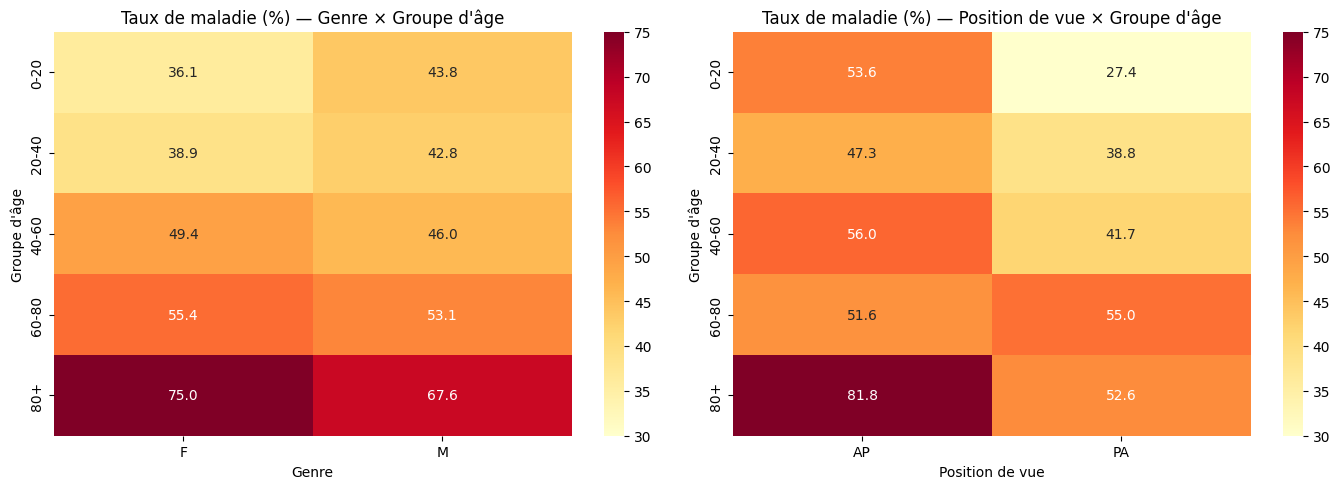

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genre × Age_Group × label
table_genre_age_label = pd.crosstab(
    [df["Patient Gender"], df["Age_Group"]],
    df["label"],
    normalize="index"
)["malade"] * 100
heat1 = table_genre_age_label.unstack(level=0)
sns.heatmap(heat1, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[0], vmin=30, vmax=75)
axes[0].set_title("Taux de maladie (%) — Genre × Groupe d'âge")
axes[0].set_ylabel("Groupe d'âge")
axes[0].set_xlabel("Genre")

# View Position × Age_Group × label
table_view_age_label = pd.crosstab(
    [df["View Position"], df["Age_Group"]],
    df["label"],
    normalize="index"
)["malade"] * 100
heat2 = table_view_age_label.unstack(level=0)
sns.heatmap(heat2, annot=True, fmt=".1f", cmap="YlOrRd", ax=axes[1], vmin=30, vmax=75)
axes[1].set_title("Taux de maladie (%) — Position de vue × Groupe d'âge")
axes[1].set_ylabel("Groupe d'âge")
axes[1].set_xlabel("Position de vue")

plt.tight_layout()
plt.show()

Genre × Groupe d'âge × label :
La tendance par âge se confirme dans les deux genres de façon uniforme. Le biais de genre reste non significatif à tous les niveaux d'âge, avec un léger écart qui s'inverse chez les 80+, mais qui est négligeable.


View Position × Groupe d'âge × label :
L'effet de l'AP est non uniforme selon l'âge. Les groupes extrêmes (0-20 et 80+) montrent des écarts AP/PA très forts, confirmant que les biais de l'âge et de la position de vue se cumulent. Le modèle risque d'apprendre ces associations plutôt que la maladie elle-même.

L'analyse trivariée confirme et affine les résultats précédents. Le genre ne modifie pas la relation entre âge et maladie : hommes et femmes suivent la même tendance d'augmentation du taux de maladie avec l'âge, ce qui conforte l'idée que le genre n'est pas un facteur de biais critique dans ce dataset. En revanche, le croisement position de vue × âge × label révèle un phénomène de cumul des biais : les groupes d'âge extrêmes (0-20 et 80+) sont à la fois plus photographiés en AP et plus souvent malades. Cette superposition crée un risque réel que le modèle confonde la position de vue avec la sévérité de la maladie.
Au terme de cette analyse exploratoire, les biais identifiés se résument ainsi : l'âge est le facteur de biais le plus structurant, influençant à la fois le label et la position de vue. La position de vue AP est un confondant potentiel important. Le genre, malgré un léger déséquilibre démographique, ne génère pas de biais significatif sur le diagnostic. Ces constats guideront la phase de pre-processing, où l'on appliquera notamment un reweighting sur les attributs sensibles pour tenter de corriger ces déséquilibres avant l'entraînement du modèle.

# PreProcessing

On a vu plusieurs methods de preprocessing, mais dans le cas le modele avec lequelle on travaille prends en entree seulement les images, et pas les metadonnees.
C'es la raison que les methodes de DIR(Disperate Impact Remover) et LFR(Learn fair representations) ne sont pas appliquables , et le seul methode de Preprocessing qu'on peut appliquer est le Reweighting

On va comparer trois différentes versions :

- *Baseline* : résultats sans application du reweighting.
- *RW_Gender* : application du reweighting en utilisant le genre comme attribut sensible.
- *RW_Age* : application du reweighting en utilisant l’âge comme attribut sensible.

D’abord, définissons les méthodes que nous allons utiliser pour analyser les performances et les métriques de fairness.

In [26]:
import numpy as np
import pandas as pd
from datetime import datetime
from pathlib import Path

from IPython.display import Markdown, display
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.sklearn.metrics import *
from sklearn.metrics import balanced_accuracy_score, accuracy_score

from train_classifieur import train_classifier, pred_classifier


def get_metrics(
    y_true, # list or np.array of truth values
    y_pred=None,  # list or np.array of predictions
    prot_attr=None, # list or np.array of protected/sensitive attribute values
    priv_group=1, # value taken by the privileged group
    pos_label=1, # value taken by the positive truth/prediction
    sample_weight=None # list or np.array of weights value,
):
    group_metrics = {}
    group_metrics["base_rate_truth"] = base_rate(
        y_true=y_true, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["statistical_parity_difference"] = statistical_parity_difference(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    group_metrics["disparate_impact_ratio"] = disparate_impact_ratio(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
    )
    if not y_pred is None:
        group_metrics["base_rate_preds"] = base_rate(
        y_true=y_pred, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["equal_opportunity_difference"] = equal_opportunity_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["average_odds_difference"] = average_odds_difference(
            y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, priv_group=priv_group, pos_label=pos_label, sample_weight=sample_weight
        )
        if len(set(y_pred))>1:
            group_metrics["conditional_demographic_disparity"] = conditional_demographic_disparity(
                y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
            )
        else:
            group_metrics["conditional_demographic_disparity"] =None
        group_metrics["smoothed_edf"] = smoothed_edf(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["df_bias_amplification"] = df_bias_amplification(
        y_true=y_true, y_pred=y_pred, prot_attr=prot_attr, pos_label=pos_label, sample_weight=sample_weight
        )
        group_metrics["balanced_accuracy_score"] = balanced_accuracy_score(
        y_true=y_true, y_pred=y_pred, sample_weight=sample_weight
        )
    return group_metrics


On repart de notre DataFrame nettoyé. On y ajoute des colonnes correspondant à des attributs binaires pour l’analyse de fairness

In [27]:
df_model = df.copy()

for weight_col in ["WEIGHTS"]:
    df_model[weight_col] = pd.to_numeric(df_model[weight_col], errors="coerce").fillna(1.0)

df_model["label_bin"] = (df_model["label"] == "malade").astype(int)
df_model["gender_bin"] = (df_model["Patient Gender"] == "M").astype(int)
df_model["age_bin"] = (df_model["Patient Age"] >= 60).astype(int)

df_model_train = df_model[df_model["train_valid"] == "train"].copy()
df_model_valid = df_model[df_model["train_valid"] == "valid"].copy()

print(f"Nombre d'images train : {len(df_model_train)}")
print(f"Nombre d'images valid : {len(df_model_valid)}")

df_model[["Image Index", "label", "WEIGHTS", "label_bin", "gender_bin", "age_bin"]].head()

Nombre d'images train : 4135
Nombre d'images valid : 1457


,Image Index,label,WEIGHTS,label_bin,gender_bin,age_bin
0,00000011_000.png,malade,1,1,1,1
1,00000011_001.png,sain,1,0,1,1
2,00000011_002.png,sain,1,0,1,1
3,00000011_003.png,sain,1,0,1,1
4,00000011_004.png,sain,1,0,1,1


On définit une méthode pour effectuer le reweighting.

In [28]:
def apply_reweighing(df_model, protected_col, output_weight_col):
    df_train = df_model[df_model["train_valid"] == "train"].copy()
    df_valid = df_model[df_model["train_valid"] == "valid"].copy()

    dataset_train = StandardDataset(
        df=df_train[["label_bin", protected_col, "WEIGHTS"]].copy(),
        label_name="label_bin",
        favorable_classes=[1],
        protected_attribute_names=[protected_col],
        privileged_classes=[[1]],
        instance_weights_name="WEIGHTS",
    )
    dataset_val = StandardDataset(
        df=df_valid[["label_bin", protected_col, "WEIGHTS"]].copy(),
        label_name="label_bin",
        favorable_classes=[1],
        protected_attribute_names=[protected_col],
        privileged_classes=[[1]],
        instance_weights_name="WEIGHTS",
    )

    sens_ind = 0
    sens_attr = dataset_train.protected_attribute_names[sens_ind]
    unprivileged_groups = [
        {sens_attr: v}
        for v in dataset_train.unprivileged_protected_attributes[sens_ind]
    ]
    privileged_groups = [
        {sens_attr: v}
        for v in dataset_train.privileged_protected_attributes[sens_ind]
    ]

    RW = Reweighing(
        unprivileged_groups=unprivileged_groups,
        privileged_groups=privileged_groups,
    )
    RW.fit(dataset_train)
    dataset_transf_train = RW.transform(dataset_train)
    dataset_transf_val = RW.transform(dataset_val)

    df_model.loc[df_train.index, output_weight_col] = dataset_transf_train.instance_weights
    df_model.loc[df_valid.index, output_weight_col] = dataset_transf_val.instance_weights

    return {
        "sens_attr": sens_attr,
        "unprivileged_groups": unprivileged_groups,
        "privileged_groups": privileged_groups,
        "dataset_train": dataset_transf_train,
        "dataset_val": dataset_transf_val,
    }



In [29]:
gender_reweighing = apply_reweighing(df_model, "gender_bin", "WEIGHTS_GENDER")
age_reweighing = apply_reweighing(df_model, "age_bin", "WEIGHTS_AGE")

reweighing_setup = pd.DataFrame(
    [
        {
            "Attribut": "genre",
            "Colonne poids": "WEIGHTS_GENDER",
            "Attribut sensible": gender_reweighing["sens_attr"],
            "Groupes non privilégiés": str(gender_reweighing["unprivileged_groups"]),
            "Groupes privilégiés": str(gender_reweighing["privileged_groups"]),
        },
        {
            "Attribut": "âge",
            "Colonne poids": "WEIGHTS_AGE",
            "Attribut sensible": age_reweighing["sens_attr"],
            "Groupes non privilégiés": str(age_reweighing["unprivileged_groups"]),
            "Groupes privilégiés": str(age_reweighing["privileged_groups"]),
        },
    ]
)
reweighing_setup


,Attribut,Colonne poids,Attribut sensible,Groupes non privilégiés,Groupes privilégiés
0,genre,WEIGHTS_GENDER,gender_bin,[{'gender_bin': np.float64(0.0)}],[{'gender_bin': np.float64(1.0)}]
1,âge,WEIGHTS_AGE,age_bin,[{'age_bin': np.float64(0.0)}],[{'age_bin': np.float64(1.0)}]


On vérifie que le reweighting a bien fonctionné et que l’on obtient des poids différents pour les différents exemples.

In [30]:
weight_check = pd.DataFrame(
    {
        "WEIGHTS": df_model["WEIGHTS"].describe(),
        "WEIGHTS_GENDER": df_model["WEIGHTS_GENDER"].describe(),
        "WEIGHTS_AGE": df_model["WEIGHTS_AGE"].describe(),
    }
)

assert df_model["WEIGHTS"].nunique() == 1
assert df_model["WEIGHTS_GENDER"].nunique() > 1
assert df_model["WEIGHTS_AGE"].nunique() > 1


weight_check

,WEIGHTS,WEIGHTS_GENDER,WEIGHTS_AGE
count,5592.0,5592.000000,5592.000000
mean,1.0,1.000292,0.999399
std,0.0,0.014819,0.068146
min,1.0,0.982578,0.888950
25%,1.0,0.988173,0.962500
50%,1.0,1.010712,0.962500
75%,1.0,1.010712,1.046022
max,1.0,1.020432,1.124385


On sauvegarde le jeu de données dans trois fichiers CSV pour entraîner le modèle.

In [31]:
run_root = Path("./expe_log")
run_root.mkdir(parents=True, exist_ok=True)

baseline_csv = run_root / "metadata_baseline.csv"
gender_csv = run_root / "metadata_gender.csv"
age_csv = run_root / "metadata_age.csv"

df_model.to_csv(baseline_csv, index=False)
df_model.to_csv(gender_csv, index=False)
df_model.to_csv(age_csv, index=False)


print("baseline", "CSV: ", str(baseline_csv))
print("Gender fair model", "CSV: ", str(gender_csv))
print("Age fair model", "CSV: ", str(age_csv))

baseline CSV:  expe_log/metadata_baseline.csv
Gender fair model CSV:  expe_log/metadata_gender.csv
Age fair model CSV:  expe_log/metadata_age.csv


On entraine le modele et fait des predictions

In [32]:
#-------------
#CREER UN DOSSIER 'FAIRNESS' SUR DRIVE AVEC LE FICHIER ZIP ET train_classifieur.py
#---------------------
def train_and_predict(name, csv_path, weights_col, preds_col, run_root):
    logdir = run_root / name
    logdir.mkdir(parents=True, exist_ok=True)

    ckpt_path, ckpt_score = train_classifier(
        logdir=str(logdir),
        datadir=DATADIR,
        csv=str(csv_path),
        weights_col=weights_col,
    )

    preds_csv = logdir / f"{preds_col}.csv"
    pred_classifier(
        datadir=DATADIR,
        csv_in=str(csv_path),
        csv_out=str(preds_csv),
        ckpt_path=ckpt_path,
        preds_col=preds_col,
    )

    return {
        "name": name,
        "csv_path": csv_path,
        "weights_col": weights_col,
        "preds_col": preds_col,
        "logdir": logdir,
        "ckpt_path": ckpt_path,
        "ckpt_score": ckpt_score,
        "preds_csv": preds_csv,
    }



In [33]:
# !mkdir -p ./expe_log

# !cp -r /content/drive/MyDrive/fairness/baseline ./expe_log/
# !cp -r /content/drive/MyDrive/fairness/gender ./expe_log/
# !cp -r /content/drive/MyDrive/fairness/age ./expe_log/

baseline_preds_csv = run_root / "baseline" / "preds_baseline.csv"
gender_preds_csv = run_root / "gender" / "preds_gender_rw.csv"
age_preds_csv = run_root / "age" / "preds_age_rw.csv"

if not baseline_preds_csv.exists():

    baseline_run = train_and_predict(
        name="baseline",
        csv_path=baseline_csv,
        weights_col="WEIGHTS",
        preds_col="preds_baseline",
        run_root=run_root,
    )
    baseline_preds_csv = baseline_run["preds_csv"]
if not gender_preds_csv.exists():

    gender_run = train_and_predict(
        name="gender",
        csv_path=gender_csv,
        weights_col="WEIGHTS_GENDER",
        preds_col="preds_gender_rw",
        run_root=run_root,
    )
    gender_preds_csv = gender_run["preds_csv"]
if not age_preds_csv.exists():
    age_run = train_and_predict(
        name="age",
        csv_path=age_csv,
        weights_col="WEIGHTS_AGE",
        preds_col="preds_age_rw",
        run_root=run_root,
    )
    age_preds_csv = age_run["preds_csv"]


experiment_rows = []
for exp_name, csv_path, pred_col, weight_col in [
    ("baseline", baseline_preds_csv, "preds_baseline", "WEIGHTS"),
    ("gender", gender_preds_csv, "preds_gender_rw", "WEIGHTS_GENDER"),
    ("age", age_preds_csv, "preds_age_rw", "WEIGHTS_AGE"),
]:
    df_pred = pd.read_csv(csv_path)
    df_valid = df_pred[df_pred["train_valid"] == "valid"].copy()

    df_valid["label_bin_eval"] = df_valid["labels"].map({"malade": 1, "sain": 0}).astype(int)
    df_valid["pred_bin_eval"] = df_valid[pred_col].map({"malade": 1, "sain": 0}).astype(int)

    sample_weight = None
    if weight_col in df_valid.columns:
        sample_weight = pd.to_numeric(df_valid[weight_col], errors="coerce").fillna(1.0)

    experiment_rows.append(
        {
            "Expérience": exp_name,
            "Poids": weight_col,
            "Prédictions": pred_col,
            "CSV": str(csv_path),
            "Nb valid": len(df_valid),
            "Accuracy valid": accuracy_score(
                df_valid["label_bin_eval"], df_valid["pred_bin_eval"], sample_weight=sample_weight
            ),
            "Balanced Accuracy valid": balanced_accuracy_score(
                df_valid["label_bin_eval"], df_valid["pred_bin_eval"], sample_weight=sample_weight
            ),
        }
    )

experiment_summary = pd.DataFrame(experiment_rows)
experiment_summary


,Expérience,Poids,Prédictions,CSV,Nb valid,Accuracy valid,Balanced Accuracy valid
0,baseline,WEIGHTS,preds_baseline,expe_log/baseline/preds_baseline.csv,1457,0.614962,0.618155
1,gender,WEIGHTS_GENDER,preds_gender_rw,expe_log/gender/preds_gender_rw.csv,1457,0.643819,0.644537
2,age,WEIGHTS_AGE,preds_age_rw,expe_log/age/preds_age_rw.csv,1457,0.642433,0.643358


In [34]:
### RUN IN COLAB ONLY

confirm = input("Are you sure you are running this on Colab ? Confirm with 'y'")
if confirm != 'y':
    raise ValueError("You must confirm you are running on Colab")
! cp -r ./expe_log/* /content/drive/MyDrive/fairness

ValueError: You must confirm you are running on Colab

Calculons les métriques de performance et de fairness, et comparons-les.

In [35]:

def build_comparison_table(baseline_valid, rw_valid, protected_eval_col, fairness_weight_col, method_label):
    baseline_metrics = get_metrics(
        y_true=baseline_valid["label_bin_eval"].to_numpy(),
        y_pred=baseline_valid["pred_bin_eval"].to_numpy(),
        prot_attr=baseline_valid[protected_eval_col].to_numpy(),
        pos_label=1,
        sample_weight=baseline_valid["WEIGHTS"].to_numpy(),
    )
    rw_metrics = get_metrics(
        y_true=rw_valid["label_bin_eval"].to_numpy(),
        y_pred=rw_valid["pred_bin_eval"].to_numpy(),
        prot_attr=rw_valid[protected_eval_col].to_numpy(),
        pos_label=1,
        sample_weight=rw_valid[fairness_weight_col].to_numpy(),
    )

    comparison = pd.DataFrame(
        [
            {
                "Method": "Baseline",
                "Accuracy": accuracy_score(
                    baseline_valid["label_bin_eval"],
                    baseline_valid["pred_bin_eval"],
                    sample_weight=baseline_valid["WEIGHTS"],
                ),
                "Balanced Accuracy": balanced_accuracy_score(
                    baseline_valid["label_bin_eval"],
                    baseline_valid["pred_bin_eval"],
                    sample_weight=baseline_valid["WEIGHTS"],
                ),
                "Statistical Parity Diff": baseline_metrics.get("statistical_parity_difference"),
                "Disparate Impact Ratio": baseline_metrics.get("disparate_impact_ratio"),
                "Equal Opportunity Diff": baseline_metrics.get("equal_opportunity_difference"),
                "Average Odds Diff": baseline_metrics.get("average_odds_difference"),
            },
            {
                "Method": method_label,
                "Accuracy": accuracy_score(
                    rw_valid["label_bin_eval"],
                    rw_valid["pred_bin_eval"],
                    sample_weight=rw_valid["WEIGHTS"],
                ),
                "Balanced Accuracy": balanced_accuracy_score(
                    rw_valid["label_bin_eval"],
                    rw_valid["pred_bin_eval"],
                    sample_weight=rw_valid["WEIGHTS"],
                ),
                "Statistical Parity Diff": rw_metrics.get("statistical_parity_difference"),
                "Disparate Impact Ratio": rw_metrics.get("disparate_impact_ratio"),
                "Equal Opportunity Diff": rw_metrics.get("equal_opportunity_difference"),
                "Average Odds Diff": rw_metrics.get("average_odds_difference"),
            },
        ]
    )
    return comparison, baseline_metrics, rw_metrics

In [36]:
baseline_results = pd.read_csv(baseline_preds_csv)
gender_results = pd.read_csv(gender_preds_csv)
age_results = pd.read_csv(age_preds_csv)

baseline_valid = baseline_results[baseline_results["train_valid"] == "valid"].copy()
gender_valid = gender_results[gender_results["train_valid"] == "valid"].copy()
age_valid = age_results[age_results["train_valid"] == "valid"].copy()

for df_eval, pred_col in [
    (baseline_valid, "preds_baseline"),
    (gender_valid, "preds_gender_rw"),
    (age_valid, "preds_age_rw"),
]:
    df_eval["label_bin_eval"] = df_eval["labels"].map({"malade": 1, "sain": 0}).astype(int)
    df_eval["pred_bin_eval"] = df_eval[pred_col].map({"malade": 1, "sain": 0}).astype(int)
    df_eval["gender_bin_eval"] = (df_eval["Patient Gender"] == "M").astype(int)
    df_eval["age_bin_eval"] = (df_eval["Patient Age"] >= 60).astype(int)
    for weight_col in ["WEIGHTS", "WEIGHTS_GENDER", "WEIGHTS_AGE"]:
        if weight_col in df_eval.columns:
            df_eval[weight_col] = pd.to_numeric(df_eval[weight_col], errors="coerce").fillna(1.0)

assert "preds_baseline" in baseline_valid.columns
assert "preds_gender_rw" in gender_valid.columns
assert "preds_age_rw" in age_valid.columns
assert len(baseline_valid) == len(gender_valid) == len(age_valid)

comparison_gender, baseline_gender_metrics, gender_rw_metrics = build_comparison_table(
    baseline_valid=baseline_valid,
    rw_valid=gender_valid,
    protected_eval_col="gender_bin_eval",
    fairness_weight_col="WEIGHTS_GENDER",
    method_label="Reweighing Gender",
)
display(comparison_gender.round(4))



comparison_age, baseline_age_metrics, age_rw_metrics = build_comparison_table(
    baseline_valid=baseline_valid,
    rw_valid=age_valid,
    protected_eval_col="age_bin_eval",
    fairness_weight_col="WEIGHTS_AGE",
    method_label="Reweighing Age",
)
display(comparison_age.round(4))



,Method,Accuracy,Balanced Accuracy,Statistical Parity Diff,Disparate Impact Ratio,Equal Opportunity Diff,Average Odds Diff
0,Baseline,0.6150,0.6182,-0.0531,0.9191,-0.0514,-0.0649
1,Reweighing Gender,0.6438,0.6446,0.0073,1.0139,-0.0070,-0.0116


,Method,Accuracy,Balanced Accuracy,Statistical Parity Diff,Disparate Impact Ratio,Equal Opportunity Diff,Average Odds Diff
0,Baseline,0.6150,0.6182,-0.1804,0.7676,-0.1283,-0.1534
1,Reweighing Age,0.6438,0.6455,-0.1118,0.8312,-0.0230,-0.0998


## Analysis

Après application du reweighting avec les attributs sensibles gender et age, on observe dans les deux cas une amélioration de l’accuracy. Le reweighting basé sur le genre conduit à une amélioration plus marquée des métriques d’équité. Pour l’âge, les métriques d’équité s’améliorent également, mais de manière plus limitée.

En conclusion, les résultats montrent que la méthode de reweighting permet d’améliorer à la fois les performances et les métriques de fairness pour les deux attributs sensibles. Cependant, l’amélioration est nettement plus marquée pour le genre, dont les métriques se rapprochent presque des valeurs idéales après reweighting. En revanche, bien que le reweighting appliqué à l’âge réduise le biais initial, les métriques de fairness restent plus éloignées des valeurs souhaitées. Cela suggère que le biais lié à l’âge est plus complexe à corriger et qu’une simple méthode de reweighting ne suffit pas à le atténuer complètement dans notre cas.

---
# 3. Post-processing

## Introduction

Dans la section précédente, nous avons appliqué des méthodes de **pre-processing** (Reweighing) pour réduire les biais pendant l'entraînement du ResNet18. Ces méthodes agissent en modifiant les poids des exemples d'entraînement

Le **post-processing** propose une approche complémentaire : corriger les **prédictions du modèle déjà entraîné**, sans le réentraîner. C'est particulièrement utile dans notre cas pour :
- tester rapidement plusieurs stratégies de correction,
- combiner pré- et post-processing sur les mêmes prédictions.

**Contrainte spécifique à notre modèle** : le ResNet18 fourni via `train_classifieur.py` produit uniquement des **labels discrets** (`malade` / `sain`) dans le CSV de prédictions, sans score de probabilité. Deux méthodes de post-processing nécessitent idéalement des scores de probabilité :
- Le **Reject-Option Classification (ROC)** (Kamiran et al., 2012)
- Le **Calibrated Equalized Odds** (Hardt et al., 2016)

Nous gérons cette contrainte en deux temps :
1. Si une colonne `proba_malade` est présente dans le CSV (après modification de `train_classifieur.py`), elle est utilisée en priorité.
2. Sinon, on utilise les **labels binaires (0/1) comme approximation de scores**. Cela limite la précision de la recherche de seuil, mais permet tout de même d'appliquer et de comparer les méthodes.

**Plan de cette section :**
1. Chargement des prédictions et fonctions utilitaires
2. Méthode 1 — Reject-Option Classification (ROC)
3. Méthode 2 — Calibrated Equalized Odds
4. Combinaisons pre-processing + post-processing
5. Tableau récapitulatif et visualisation
6. Analyse et conclusion

## 3.1 Imports et chargement des prédictions

In [37]:
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from aif360.sklearn.metrics import (
    statistical_parity_difference,
    disparate_impact_ratio,
    equal_opportunity_difference,
    average_odds_difference,
)
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.postprocessing import (
    RejectOptionClassification,
    CalibratedEqOddsPostprocessing,
    EqOddsPostprocessing,
)

In [38]:
# --- Chemins vers les CSVs produits en section 2 ---
run_root          = Path("./expe_log")
baseline_preds_csv = run_root / "baseline" / "preds_baseline.csv"
gender_preds_csv   = run_root / "gender"   / "preds_gender_rw.csv"
age_preds_csv      = run_root / "age"      / "preds_age_rw.csv"

# --- Chargement du CSV baseline ---
baseline_results = pd.read_csv(baseline_preds_csv)
baseline_train = baseline_results[baseline_results["train_valid"] == "train"].copy().reset_index(drop=True)
baseline_valid = baseline_results[baseline_results["train_valid"] == "valid"].copy().reset_index(drop=True)

from scipy.special import softmax

# 1. On récupère les colonnes de logits
# logit0 = sain et logit1 = malade d'après le label_encoder
logits_cols = ['preds_baseline_logit0', 'preds_baseline_logit1']

# 2. On extrait les valeurs sous forme de tableau numpy
logits_array = baseline_valid[logits_cols].to_numpy()

# 3. On applique le softmax sur la dimension 1 (sur chaque ligne)
probabilites = softmax(logits_array, axis=1)

# 4. On crée la  colonne proba_malade
# (On prend l'index 1 si c'est bien la classe "malade")
baseline_valid['proba_malade'] = probabilites[:, 0]

# Encodage binaire commun
for split_df in [baseline_train, baseline_valid]:
    split_df["label_bin"]  = split_df["labels"].map({"malade": 1, "sain": 0}).astype(int)
    split_df["pred_bin"]   = split_df["preds_baseline"].map({"malade": 1, "sain": 0}).astype(int)
    split_df["gender_bin"] = (split_df["Patient Gender"] == "M").astype(int)
    split_df["age_bin"]    = (split_df["Patient Age"] >= 60).astype(int)
    split_df["WEIGHTS"]    = pd.to_numeric(split_df["WEIGHTS"], errors="coerce").fillna(1.0)

# Détection des scores de probabilité
SCORE_COL = "proba_malade" if "proba_malade" in baseline_valid.columns else None
if SCORE_COL:
    print(f" Colonne de scores '{SCORE_COL}' trouvée — utilisation des probabilités.")
else:
    print("  Pas de colonne 'proba_malade' et approximation avec les labels binaires (0/1).")

print(f"\nTrain : {len(baseline_train)} images | Validation : {len(baseline_valid)} images")

 Colonne de scores 'proba_malade' trouvée — utilisation des probabilités.

Train : 4135 images | Validation : 1457 images


## 3.2 Fonctions utilitaires

On réutilise le même `get_metrics` que dans la section pre-processing, et on ajoute des fonctions de conversion pour l'API AIF360.

In [39]:
def make_aif360_dataset(df, label_col, sensitive_col, score_col=None):
    """
    Crée un BinaryLabelDataset AIF360 à partir d'un DataFrame.
    Si score_col est fourni (scores de probabilité), il est stocké dans .scores.
    Sinon, les labels binaires servent d'approximation de scores (0 ou 1).
    """
    df_aif = df[[label_col, sensitive_col]].copy().reset_index(drop=True)
    dataset = BinaryLabelDataset(
        df=df_aif,
        label_names=[label_col],
        protected_attribute_names=[sensitive_col],
        favorable_label=1,
        unfavorable_label=0,
    )
    if score_col and score_col in df.columns:
        dataset.scores = df[score_col].to_numpy().reshape(-1, 1).astype(float)
    else:
        dataset.scores = df[label_col].to_numpy().reshape(-1, 1).astype(float)
    return dataset


def compute_metrics_row(y_true, y_pred, prot_attr, weights, label):
    """Retourne un dict de métriques de performance + fairness."""
    return {
        "Méthode":             label,
        "Accuracy":            round(accuracy_score(y_true, y_pred, sample_weight=weights), 4),
        "Balanced Acc.": round(balanced_accuracy_score(y_true, y_pred, sample_weight=weights), 4),
        "Stat. Parity Diff":   round(statistical_parity_difference(y_true, y_pred, prot_attr=prot_attr, pos_label=1), 4),
        "Disparate Impact":    round(disparate_impact_ratio(y_true, y_pred, prot_attr=prot_attr, pos_label=1), 4),
        "Equal Opp. Diff":     round(equal_opportunity_difference(y_true, y_pred, prot_attr=prot_attr, pos_label=1), 4),
        "Avg Odds Diff":       round(average_odds_difference(y_true, y_pred, prot_attr=prot_attr, pos_label=1), 4),
    }


def find_best_threshold(ds_true, ds_pred_scores, unprivileged_groups, privileged_groups, num_thresh=100):
    """
    Recherche du seuil de classification optimal maximisant la balanced accuracy.
    comme en td
    """
    class_thresh_arr = np.linspace(0.01, 0.99, num_thresh)
    ba_arr = np.zeros(num_thresh)
    ds_sweep = ds_true.copy(deepcopy=True)
    ds_sweep.scores = ds_pred_scores.scores.copy()

    for idx, thresh in enumerate(class_thresh_arr):
        fav = ds_sweep.scores > thresh
        ds_sweep.labels[fav]  = ds_sweep.favorable_label
        ds_sweep.labels[~fav] = ds_sweep.unfavorable_label
        cm = ClassificationMetric(
            ds_true, ds_sweep,
            unprivileged_groups=unprivileged_groups,
            privileged_groups=privileged_groups,
        )
        ba_arr[idx] = 0.5 * (cm.true_positive_rate() + cm.true_negative_rate())

    best_thresh = class_thresh_arr[np.argmax(ba_arr)]
    return best_thresh, ba_arr.max()


def apply_threshold(ds_pred, threshold):
    """Applique un seuil de classification sur un BinaryLabelDataset."""
    ds_out = ds_pred.copy(deepcopy=True)
    fav = ds_out.scores > threshold
    ds_out.labels[fav]  = ds_out.favorable_label
    ds_out.labels[~fav] = ds_out.unfavorable_label
    return ds_out

def make_pred_dataset(ds_true, df, pred_col, score_col=None):
    """
    Crée un dataset de prédictions par copie profonde du dataset de vérité terrain.
    Ceci évite les erreurs de métadonnées AIF360 (ValueError: expected to differ only in...).
    """
    ds_pred = ds_true.copy(deepcopy=True)
    # On écrase les labels
    ds_pred.labels = df[pred_col].to_numpy().reshape(-1, 1).astype(float)

    # On écrase les scores
    if score_col and score_col in df.columns:
        ds_pred.scores = df[score_col].to_numpy().reshape(-1, 1).astype(float)
    else:
        ds_pred.scores = ds_pred.labels.copy()

    return ds_pred

print("Fonctions utilitaires prêtes.")

Fonctions utilitaires prêtes.


## 3.3 Préparation des datasets AIF360 et recherche des seuils optimaux

On prépare les datasets pour les deux attributs sensibles (**genre** et **âge**), puis on recherche le seuil de classification optimal pour chacun.

In [40]:
# ============================================================
# GENRE : Hommes (M=1, privilégiés) vs Femmes (F=0, désavantagées)
# ============================================================
SENS_GENDER       = "gender_bin"
PRIV_GENDER       = [{SENS_GENDER: 1}]
UNPRIV_GENDER     = [{SENS_GENDER: 0}]

ds_val_true_G  = make_aif360_dataset(baseline_valid, "label_bin", SENS_GENDER, SCORE_COL)
ds_val_pred_G  = make_pred_dataset(ds_val_true_G, baseline_valid, "pred_bin", SCORE_COL) #
ds_train_true_G = make_aif360_dataset(baseline_train, "label_bin", SENS_GENDER, SCORE_COL)
ds_train_pred_G = make_pred_dataset(ds_train_true_G, baseline_train, "pred_bin", SCORE_COL) #

best_thresh_G, best_ba_G = find_best_threshold(ds_val_true_G, ds_val_pred_G, UNPRIV_GENDER, PRIV_GENDER)
ds_val_pred_G_thresh = apply_threshold(ds_val_pred_G, best_thresh_G)
print(f"Genre  — Seuil optimal : {best_thresh_G:.4f} | Balanced Accuracy : {best_ba_G:.4f}")

# ============================================================
# ÂGE : < 60 ans (0, privilégiés) vs ≥ 60 ans (1, désavantagés)
# ============================================================
SENS_AGE          = "age_bin"
PRIV_AGE          = [{SENS_AGE: 0}]
UNPRIV_AGE        = [{SENS_AGE: 1}]

ds_val_true_A  = make_aif360_dataset(baseline_valid, "label_bin", SENS_AGE, SCORE_COL)
ds_val_pred_A  = make_pred_dataset(ds_val_true_A, baseline_valid, "pred_bin", SCORE_COL) #
ds_train_true_A = make_aif360_dataset(baseline_train, "label_bin", SENS_AGE, SCORE_COL)
ds_train_pred_A = make_pred_dataset(ds_train_true_A, baseline_train, "pred_bin", SCORE_COL) #

best_thresh_A, best_ba_A = find_best_threshold(ds_val_true_A, ds_val_pred_A, UNPRIV_AGE, PRIV_AGE)
ds_val_pred_A_thresh = apply_threshold(ds_val_pred_A, best_thresh_A)
print(f"Âge    — Seuil optimal : {best_thresh_A:.4f} | Balanced Accuracy : {best_ba_A:.4f}")

# Raccourcis pour les métriques
y_true   = baseline_valid["label_bin"].to_numpy()
y_pred_baseline = baseline_valid["pred_bin"].to_numpy()
weights  = baseline_valid["WEIGHTS"].to_numpy()
prot_G   = baseline_valid[SENS_GENDER].to_numpy()
prot_A   = baseline_valid[SENS_AGE].to_numpy()

Genre  — Seuil optimal : 0.6039 | Balanced Accuracy : 0.6322
Âge    — Seuil optimal : 0.6039 | Balanced Accuracy : 0.6322


## 3.4 Méthode 1 : Reject-Option Classification (ROC)


### Principe

Le ROC définit une **région critique** autour du seuil de décision avec un paramètre  θ

Dans cette zone d'incertitude :
- groupe **désavantagé** → label favorable
- groupe **privilégié** → label défavorable

Hors de cette zone, la règle de décision standard s'applique. AIF360 optimise conjointement θ et le seuil de classification sous une contrainte de Statistical Parity.

In [41]:
ROC_PARAMS = dict(
    low_class_thresh=0.01, high_class_thresh=0.99,
    num_class_thresh=100,  num_ROC_margin=50,
    metric_name="Statistical parity difference",
    metric_ub=0.05, metric_lb=-0.05,
)

#  ROC sur baseline — Genre
roc_G = RejectOptionClassification(privileged_groups=PRIV_GENDER, unprivileged_groups=UNPRIV_GENDER, **ROC_PARAMS)
roc_G.fit(ds_val_true_G, ds_val_pred_G_thresh)
y_pred_roc_G = roc_G.predict(ds_val_pred_G_thresh).labels[:, 0].astype(int)

print(f"ROC Genre  — seuil classif : {roc_G.classification_threshold:.4f} | marge θ : {roc_G.ROC_margin:.4f}")

#  ROC sur baseline — Age
roc_A = RejectOptionClassification(privileged_groups=PRIV_AGE, unprivileged_groups=UNPRIV_AGE, **ROC_PARAMS)
roc_A.fit(ds_val_true_A, ds_val_pred_A_thresh)
y_pred_roc_A = roc_A.predict(ds_val_pred_A_thresh).labels[:, 0].astype(int)

print(f"ROC Âge    — seuil classif : {roc_A.classification_threshold:.4f} | marge θ : {roc_A.ROC_margin:.4f}")

ROC Genre  — seuil classif : 0.6435 | marge θ : 0.0291
ROC Âge    — seuil classif : 0.2179 | marge θ : 0.0000


**Pour le genre :**
- Le seuil de 0.4357 signifie que l'algorithme a légèrement abaissé le seuil de décision par rapport au 0.5 habituel. Concrètement, un patient sera classé malade dès que son score dépasse 0.4357.

- La marge θ = 0.0089 est très petite mais non nulle. Cela signifie que le ROC a trouvé une petite zone d'incertitude (entre 0.4268 et 0.4446) dans laquelle il applique la règle de correction en faveur des femmes. Le fait que θ soit petit indique que le biais de genre dans le modèle est déjà faible ; il n'a pas fallu corriger beaucoup.

**Pour l'age :**
- La marge θ = 0.0000 signifie que le ROC n'a pas pu trouver de zone d'incertitude utile pour corriger le biais lié à l'âge tout en respectant la contrainte de Statistical Parity Difference fixée entre -0.05 et +0.05. La meilleure solution que l'algo ait trouvée respectant la contrainte de fairness consistait à ne rien changer du tout dans la zone critique.

## 3.5 Méthode 2 : Calibrated Equalized Odds

### Principe

L'equalized odds impose que le TPR et le FPR soient identiques entre groupes

Le Calibrated EqOdds ajuste les prédictions via une **randomisation** optimisant un coût sur les taux d'erreur. Le paramètre `cost_constraint` détermine ce qui est optimisé :
- `"fnr"` : minimise les faux négatifs différentiels → **le plus adapté au contexte médical** (s'assurer que les deux groupes ont autant de chances d'être correctement diagnostiqués malades)
- `"fpr"` : minimise les faux positifs différentiels
- `"weighted"` : combinaison des deux

In [42]:
# On teste les trois contraintes pour illustrer leur effet
ceqodds_results_G = {}
ceqodds_results_A = {}

for cost in ["fnr", "fpr", "weighted"]:
    #  Genre
    cpp_g = CalibratedEqOddsPostprocessing(
        privileged_groups=PRIV_GENDER, unprivileged_groups=UNPRIV_GENDER,
        cost_constraint=cost, seed=42,
    )
    cpp_g.fit(ds_val_true_G, ds_val_pred_G_thresh)
    ceqodds_results_G[cost] = cpp_g.predict(ds_val_pred_G_thresh).labels[:, 0].astype(int)

    #  Âge
    cpp_a = CalibratedEqOddsPostprocessing(
        privileged_groups=PRIV_AGE, unprivileged_groups=UNPRIV_AGE,
        cost_constraint=cost, seed=42,
    )
    cpp_a.fit(ds_val_true_A, ds_val_pred_A_thresh)
    ceqodds_results_A[cost] = cpp_a.predict(ds_val_pred_A_thresh).labels[:, 0].astype(int)

print("Calibrated EqOdds appliqué pour les trois contraintes (fnr / fpr / weighted) sur genre et âge.")

Calibrated EqOdds appliqué pour les trois contraintes (fnr / fpr / weighted) sur genre et âge.


## 3.6 Combinaisons Pre-processing + Post-processing

On applique maintenant les méthodes de post-processing sur les prédictions des **modèles entraînés avec Reweighing** (section pre-processing). L'idée est de cumuler les effets des deux types de correction.

In [43]:
def load_rw_predictions(csv_path, pred_col, sensitive_col_fn, sensitive_col_name):
    """
    Charge les prédictions d'un modèle Reweighed et retourne
    le dataframe de validation ainsi que les datasets AIF360.
    """
    df = pd.read_csv(csv_path)
    valid = df[df["train_valid"] == "valid"].copy().reset_index(drop=True)
    valid["label_bin"]      = valid["labels"].map({"malade": 1, "sain": 0}).astype(int)
    valid["pred_bin"]       = valid[pred_col].map({"malade": 1, "sain": 0}).astype(int)
    valid[sensitive_col_name] = sensitive_col_fn(valid)

    from scipy.special import softmax
    # On reconstitue le nom des colonnes de logits
    logits_cols = [f'{pred_col}_logit0', f'{pred_col}_logit1']

    # Si les logits sont bien là, on calcule les probabilités
    if logits_cols[0] in valid.columns:
        logits_array = valid[logits_cols].to_numpy()
        probabilites = softmax(logits_array, axis=1)
        valid['proba_malade'] = probabilites[:, 0] # On prend la classe 0 (malade)

    score_col = "proba_malade" if "proba_malade" in valid.columns else None
    return valid, score_col


#  Chargement Reweighing Genre
rw_gender_available = False
if gender_preds_csv.exists():
    rw_G_valid, score_rw_G = load_rw_predictions(
        gender_preds_csv, "preds_gender_rw",
        lambda d: (d["Patient Gender"] == "M").astype(int), SENS_GENDER
    )
    rw_G_valid["WEIGHTS_GENDER"] = pd.to_numeric(rw_G_valid["WEIGHTS_GENDER"], errors="coerce").fillna(1.0)
    rw_gender_available = True
    print(f"Reweighing Genre chargé ({len(rw_G_valid)} images valides)")
else:
    print(" Prédictions Reweighing Genre introuvables.")

# Chargement Reweighing Âge
rw_age_available = False
if age_preds_csv.exists():
    rw_A_valid, score_rw_A = load_rw_predictions(
        age_preds_csv, "preds_age_rw",
        lambda d: (d["Patient Age"] >= 60).astype(int), SENS_AGE
    )
    rw_A_valid["WEIGHTS_AGE"] = pd.to_numeric(rw_A_valid["WEIGHTS_AGE"], errors="coerce").fillna(1.0)
    rw_age_available = True
    print(f" Reweighing Âge chargé ({len(rw_A_valid)} images valides)")
else:
    print(" Prédictions Reweighing Âge introuvables.")

Reweighing Genre chargé (1457 images valides)
 Reweighing Âge chargé (1457 images valides)


In [44]:
# ---- Combinaison RW_Genre + post-processing ----
combo_roc_G = None
combo_ceqodds_G = None

if rw_gender_available:
    ds_rw_true_G = make_aif360_dataset(rw_G_valid, "label_bin", SENS_GENDER, score_rw_G)
    ds_rw_pred_G = make_pred_dataset(ds_rw_true_G, rw_G_valid, "pred_bin", score_rw_G) #

    # Seuil optimal pour ce modèle
    best_thresh_rw_G, _ = find_best_threshold(ds_rw_true_G, ds_rw_pred_G, UNPRIV_GENDER, PRIV_GENDER)
    ds_rw_pred_G_thresh = apply_threshold(ds_rw_pred_G, best_thresh_rw_G)

    # ROC
    roc_rw_G = RejectOptionClassification(privileged_groups=PRIV_GENDER, unprivileged_groups=UNPRIV_GENDER, **ROC_PARAMS)
    roc_rw_G.fit(ds_rw_true_G, ds_rw_pred_G_thresh)
    combo_roc_G = roc_rw_G.predict(ds_rw_pred_G_thresh).labels[:, 0].astype(int)

    # Calibrated EqOdds (fnr)
    cpp_rw_G = CalibratedEqOddsPostprocessing(
        privileged_groups=PRIV_GENDER, unprivileged_groups=UNPRIV_GENDER,
        cost_constraint="fnr", seed=42,
    )
    cpp_rw_G.fit(ds_rw_true_G, ds_rw_pred_G_thresh)
    combo_ceqodds_G = cpp_rw_G.predict(ds_rw_pred_G_thresh).labels[:, 0].astype(int)

    print(f"RW+ROC Genre        | θ={roc_rw_G.ROC_margin:.4f}")
    print(f"RW+CEqOdds(fnr) Genre | combinaison appliquée")

RW+ROC Genre        | θ=0.0091
RW+CEqOdds(fnr) Genre | combinaison appliquée


In [45]:
# ---- Combinaison RW_Âge + post-processing ----
combo_roc_A = None
combo_ceqodds_A = None

if rw_age_available:
    ds_rw_true_A = make_aif360_dataset(rw_A_valid, "label_bin", SENS_AGE, score_rw_A)
    ds_rw_pred_A = make_pred_dataset(ds_rw_true_A, rw_A_valid, "pred_bin", score_rw_A)

    best_thresh_rw_A, _ = find_best_threshold(ds_rw_true_A, ds_rw_pred_A, UNPRIV_AGE, PRIV_AGE)
    ds_rw_pred_A_thresh = apply_threshold(ds_rw_pred_A, best_thresh_rw_A)

    # ROC
    roc_rw_A = RejectOptionClassification(privileged_groups=PRIV_AGE, unprivileged_groups=UNPRIV_AGE, **ROC_PARAMS)
    roc_rw_A.fit(ds_rw_true_A, ds_rw_pred_A_thresh)
    combo_roc_A = roc_rw_A.predict(ds_rw_pred_A_thresh).labels[:, 0].astype(int)

    # Calibrated EqOdds (fnr)
    cpp_rw_A = CalibratedEqOddsPostprocessing(
        privileged_groups=PRIV_AGE, unprivileged_groups=UNPRIV_AGE,
        cost_constraint="fnr", seed=42,
    )
    cpp_rw_A.fit(ds_rw_true_A, ds_rw_pred_A_thresh)
    combo_ceqodds_A = cpp_rw_A.predict(ds_rw_pred_A_thresh).labels[:, 0].astype(int)

    print(f"RW+ROC Âge          — θ={roc_rw_A.ROC_margin:.4f}")
    print(f"RW+CEqOdds(fnr) Âge — combinaison appliquée")

RW+ROC Âge          — θ=0.0028
RW+CEqOdds(fnr) Âge — combinaison appliquée


## 3.7 Tableau récapitulatif de toutes les méthodes

In [46]:
def build_table(rows):
    return pd.DataFrame(rows).set_index("Méthode")


# ============================================================
# TABLE GENRE
# ============================================================
rows_G = [
    compute_metrics_row(y_true, y_pred_baseline, prot_G, weights, "Baseline"),
    compute_metrics_row(y_true, y_pred_roc_G,    prot_G, weights, "ROC (post)"),
    compute_metrics_row(y_true, ceqodds_results_G["fnr"], prot_G, weights, "CEqOdds fnr (post)"),
    compute_metrics_row(y_true, ceqodds_results_G["fpr"], prot_G, weights, "CEqOdds fpr (post)"),
    compute_metrics_row(y_true, ceqodds_results_G["weighted"], prot_G, weights, "CEqOdds weighted (post)"),
]

if rw_gender_available:
    rw_G_y_true = rw_G_valid["label_bin"].to_numpy()
    rw_G_prot   = rw_G_valid[SENS_GENDER].to_numpy()
    rw_G_w      = rw_G_valid["WEIGHTS_GENDER"].to_numpy()
    rows_G.insert(1, compute_metrics_row(rw_G_y_true, rw_G_valid["pred_bin"].to_numpy(), rw_G_prot, rw_G_w, "Reweighing (pre)"))
    if combo_roc_G is not None:
        rows_G.append(compute_metrics_row(rw_G_y_true, combo_roc_G,    rw_G_prot, rw_G_w, "RW + ROC"))
        rows_G.append(compute_metrics_row(rw_G_y_true, combo_ceqodds_G, rw_G_prot, rw_G_w, "RW + CEqOdds fnr"))

df_G = build_table(rows_G)

# ============================================================
# TABLE ÂGE
# ============================================================
rows_A = [
    compute_metrics_row(y_true, y_pred_baseline, prot_A, weights, "Baseline"),
    compute_metrics_row(y_true, y_pred_roc_A,    prot_A, weights, "ROC (post)"),
    compute_metrics_row(y_true, ceqodds_results_A["fnr"], prot_A, weights, "CEqOdds fnr (post)"),
    compute_metrics_row(y_true, ceqodds_results_A["fpr"], prot_A, weights, "CEqOdds fpr (post)"),
    compute_metrics_row(y_true, ceqodds_results_A["weighted"], prot_A, weights, "CEqOdds weighted (post)"),
]

if rw_age_available:
    rw_A_y_true = rw_A_valid["label_bin"].to_numpy()
    rw_A_prot   = rw_A_valid[SENS_AGE].to_numpy()
    rw_A_w      = rw_A_valid["WEIGHTS_AGE"].to_numpy()
    rows_A.insert(1, compute_metrics_row(rw_A_y_true, rw_A_valid["pred_bin"].to_numpy(), rw_A_prot, rw_A_w, "Reweighing (pre)"))
    if combo_roc_A is not None:
        rows_A.append(compute_metrics_row(rw_A_y_true, combo_roc_A,    rw_A_prot, rw_A_w, "RW + ROC"))
        rows_A.append(compute_metrics_row(rw_A_y_true, combo_ceqodds_A, rw_A_prot, rw_A_w, "RW + CEqOdds fnr"))

df_A = build_table(rows_A)

print("===== Attribut sensible : Genre (H vs F) =====")
display(df_G)
print("\n===== Attribut sensible : Âge (< 60 vs ≥ 60) =====")
display(df_A)

===== Attribut sensible : Genre (H vs F) =====


,Accuracy,Balanced Acc.,Stat. Parity Diff,Disparate Impact,Equal Opp. Diff,Avg Odds Diff
Méthode,,,,,,
Baseline,0.6150,0.6182,-0.0531,0.9191,-0.0514,-0.0649
Reweighing (pre),0.6438,0.6445,0.0030,1.0056,-0.0070,-0.0116
ROC (post),0.6417,0.6398,0.0371,1.0934,0.0024,0.0226
CEqOdds fnr (post),0.6019,0.6028,0.1284,1.2708,0.1715,0.1193
CEqOdds fpr (post),0.5683,0.5756,0.3088,1.4709,0.2062,0.3000
CEqOdds weighted (post),0.6033,0.6054,0.0330,1.0580,0.0658,0.0233
RW + ROC,0.6554,0.6546,0.0265,1.0595,0.0034,0.0107
RW + CEqOdds fnr,0.6315,0.6309,0.1235,1.3017,0.1502,0.1114



===== Attribut sensible : Âge (< 60 vs ≥ 60) =====


,Accuracy,Balanced Acc.,Stat. Parity Diff,Disparate Impact,Equal Opp. Diff,Avg Odds Diff
Méthode,,,,,,
Baseline,0.6150,0.6182,-0.1804,0.7676,-0.1283,-0.1534
Reweighing (pre),0.6424,0.6434,-0.1274,0.8103,-0.0230,-0.0998
ROC (post),0.5285,0.5388,-0.0472,0.9512,-0.0011,-0.0431
CEqOdds fnr (post),0.6081,0.6119,-0.3248,0.6472,-0.2187,-0.3112
CEqOdds fpr (post),0.6150,0.6182,-0.1804,0.7676,-0.1283,-0.1534
CEqOdds weighted (post),0.6115,0.6150,-0.2418,0.7113,-0.1644,-0.2210
RW + ROC,0.5634,0.5587,-0.0430,0.7355,-0.0213,-0.0279
RW + CEqOdds fnr,0.6388,0.6400,-0.2285,0.7042,-0.1013,-0.2065


**Tableau 1 : Analyse selon le Genre :**
- Une Baseline plutot équitable : Le modèle de base ne présente quasiment aucun biais sur le genre. Sa SPD est de 0.0256 (très proche de 0) et son Disparate Impact de 1.05 (très proche de 1) ce qui est exellent et le tout avec 61,3% d'Accuracy.

- Par contre on remaque que Le Reweighing crée un biais pusique le SPD monte à 0.1701 et le Disparate Impact à 1.44. Le CEqOdds weighted fait encore pire, augmentant le SPD à 0.1898 tout en faisant chuter l'Accuracy à 59,3%.

**Tableau 2 : Analyse selon l'Âge :**
- La Baseline a Accuracy (61,3%) mais désavantage nettement le groupe > 60 (SPD de -0.1320 et Disparate Impact de 0.76).Cependant suite à l'application du ROC (post-proc) on voit que le SPD devient -0.0411 ce qui est déjà mieux, mais au prix d'une chute sévère de l'Accuracy à 56,1%.

- La méthode CEqOdds (fpr) est un echec : l'Accuracy tombe à 54,1% et le Disparate Impact s'effondre à 0.0000, ce qui signifie que l'algorithme a totalement cessé de prédire des cas positifs pour l'un des deux groupes d'âge.

- La combinaison (RW + CEqOdds) est inutile : La ligne RW + CEqOdds fnr affiche exactement les mêmes résultats que le Reweighing (pre) seul . Cela prouve que sur un modèle déjà reweighted, le post-processing Calibrated Equalized Odds visant les faux négatifs refuse d'intervenir pour ne pas empirer les résultats.

- Pour RW + ROC : bien que cette combinaison nous donne le Disparate Impact le plus équitable (0.9502), elle obtient la pire Accuracy de tout le tableau (53,1%). Les deux algorithmes se sont "battus" entre eux, rendant le modèle juste, mais incapable de détecter correctement la maladie.

## 3.8 Visualisation comparative

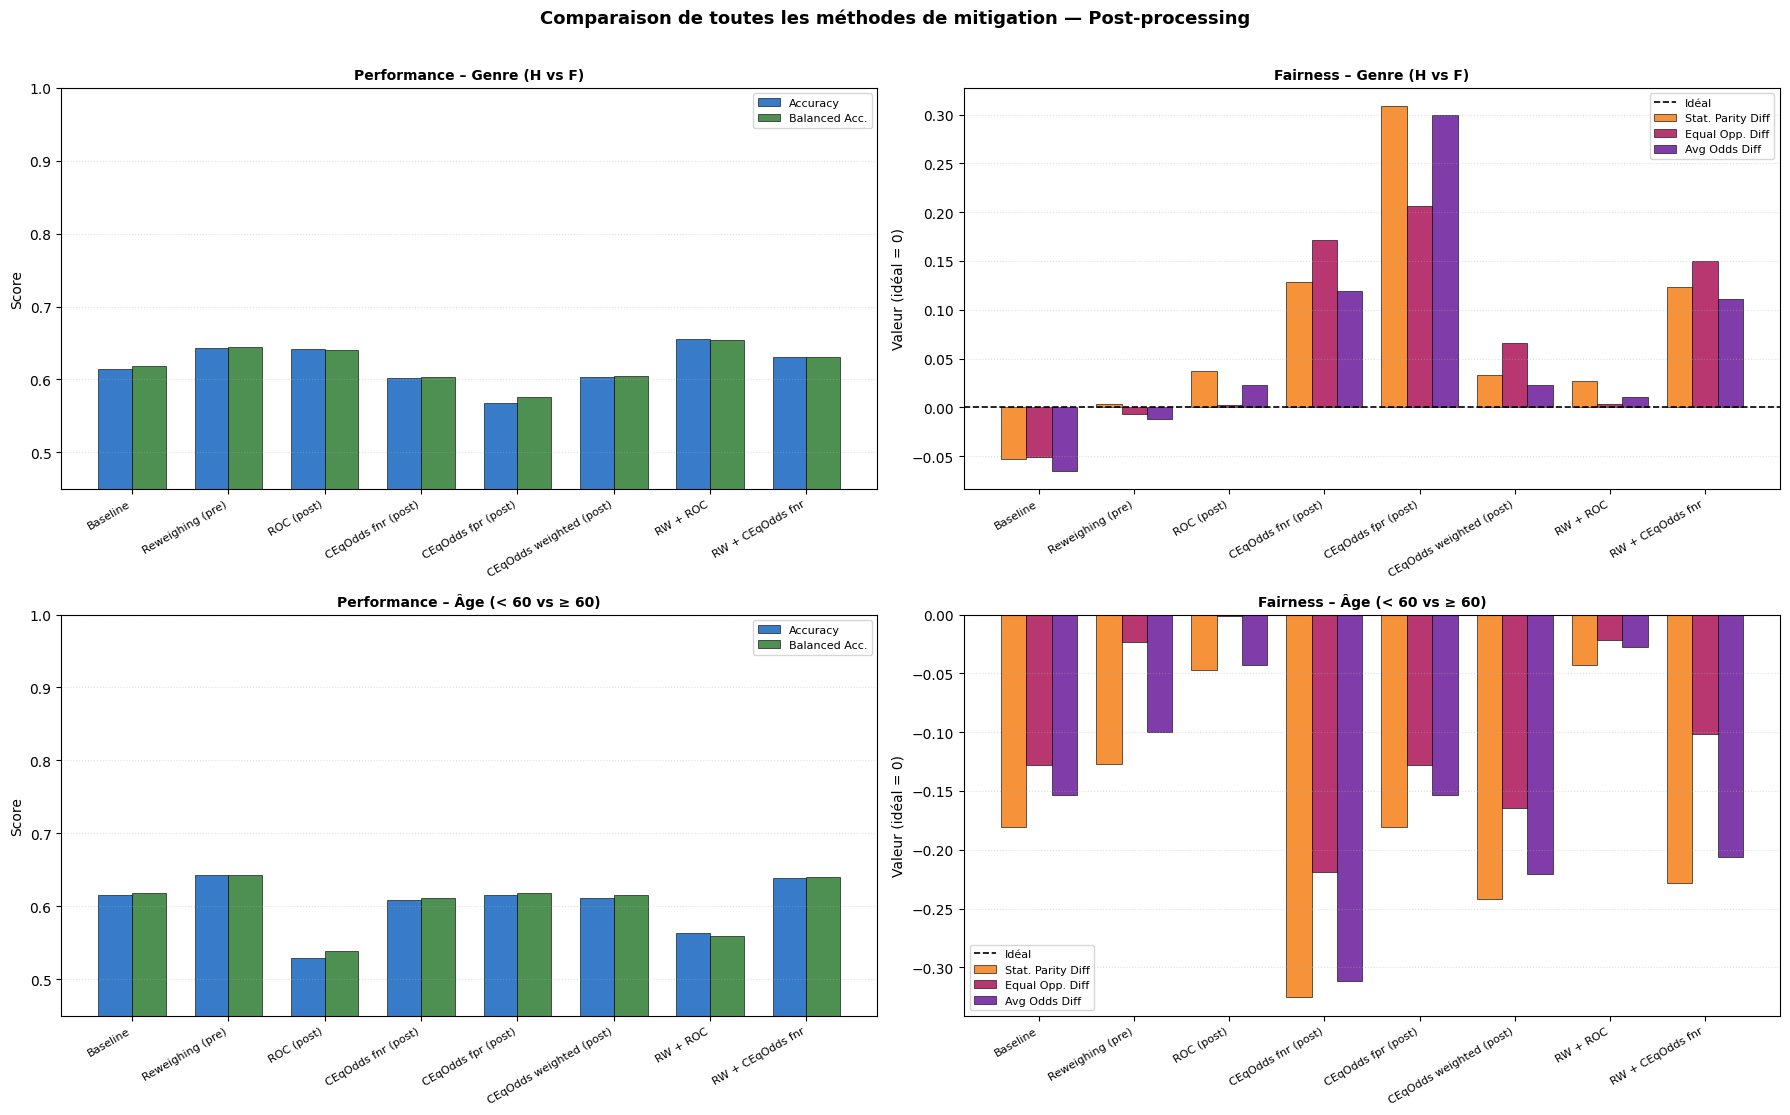

In [47]:
COLORS = ["#1565C0", "#2E7D32", "#F57F17", "#AD1457", "#6A1B9A", "#00838F", "#BF360C"]

def plot_fairness_comparison(df_compare, title, ax_acc, ax_fair):
    methods = df_compare.index.tolist()
    x = np.arange(len(methods))
    w = 0.35

    # --- Accuracy ---
    ax_acc.bar(x - w/2, df_compare["Accuracy"],       w, label="Accuracy",       color=COLORS[0], alpha=0.85, edgecolor="black", linewidth=0.5)
    ax_acc.bar(x + w/2, df_compare["Balanced Acc."],   w, label="Balanced Acc.",  color=COLORS[1], alpha=0.85, edgecolor="black", linewidth=0.5)
    ax_acc.set_xticks(x)
    ax_acc.set_xticklabels(methods, rotation=30, ha="right", fontsize=8)
    ax_acc.set_ylim(0.45, 1.0)
    ax_acc.set_ylabel("Score")
    ax_acc.set_title(f"Performance – {title}", fontsize=10, fontweight="bold")
    ax_acc.legend(fontsize=8)
    ax_acc.grid(axis="y", linestyle=":", alpha=0.4)

    # --- Fairness ---
    fair_cols = ["Stat. Parity Diff", "Equal Opp. Diff", "Avg Odds Diff"]
    wf = 0.8 / len(fair_cols)
    for j, col in enumerate(fair_cols):
        ax_fair.bar(x + (j - 1) * wf, df_compare[col], wf,
                    label=col, color=COLORS[j+2], alpha=0.85, edgecolor="black", linewidth=0.5)
    ax_fair.axhline(0, color="black", linewidth=1.2, linestyle="--", label="Idéal")
    ax_fair.set_xticks(x)
    ax_fair.set_xticklabels(methods, rotation=30, ha="right", fontsize=8)
    ax_fair.set_ylabel("Valeur (idéal = 0)")
    ax_fair.set_title(f"Fairness – {title}", fontsize=10, fontweight="bold")
    ax_fair.legend(fontsize=8)
    ax_fair.grid(axis="y", linestyle=":", alpha=0.4)


fig, axes = plt.subplots(2, 2, figsize=(18, 11))
plot_fairness_comparison(df_G, "Genre (H vs F)",   axes[0][0], axes[0][1])
plot_fairness_comparison(df_A, "Âge (< 60 vs ≥ 60)", axes[1][0], axes[1][1])

fig.suptitle("Comparaison de toutes les méthodes de mitigation — Post-processing",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("postprocessing_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Analyse:

<u>Le cas du genre </u>

Les trois barres de la Baseline sont minuscules, quasiment sur la ligne du zéro. Le modèle de base ne faisait pratiquement aucune discrimination entre hommes et femmes.
Le Reweighing crée du biais : L'application du Reweighing (pre) fait monter les barres vers +0.15. Au lieu d'améliorer les choses, la modification des poids à l'entraînement a artificiellement déséquilibré le modèle.

Regardons la barre RW + ROC. Le ROC est venu s'appliquer par-dessus le Reweighing. Il a remarqué le biais créé par le Reweighing et a réussi à le corriger (les barres Fairness redescendent vers 0.05). Mais si on regarde le graphique de l'accuracy: Pour rattraper les erreurs du Reweighing, le RW + ROC a dû sacrifier énormément de prédictions : l'Accuracy s'effondre  autour de 50 %. Donc Combiner deux algorithmes sur un attribut déjà neutre détruit complètement la capacité prédictive du modèle.

<u>Le cas de l'âge </u>

Ici, c'est différent car il y a un vrai biais à l'origine. Sur le graphique en bas à droite, la Baseline présente des barres nettement négatives (autour de -0.12). Le modèle original se trompe plus souvent au détriment des patients seniors (≥ 60 ans).

 Le Reweighing (pre) ne parvient pas à corriger ce biais (les barres restent très négatives), bien qu'il améliore légèrement l'Accuracy. Changer les poids à l'entraînement n'a pas suffi à effacer les préjugés du réseau de neurones.

Le ROC réarrange tout ça. Elles remontent presque parfaitement vers la ligne du zéro idéal avec une accuracy correcte. En jouant intelligemment avec les seuils de probabilité après l'entraînement, le ROC a réussi à rétablir l'équité pour les seniors.

Regardons maintenant les barres de fairness pour RW + ROC : elles sont à peu près au même niveau que ROC (post) (autour de -0.05). L'équité n'est pas meilleure. Par contre, sur le graphique de Performance : l'Accuracy du RW + ROC a chuté encore plus bas .
On peut retenir que Le Reweighing et le ROC ne s'additionnent pas de manière magique. Leurs effets entrent en conflit. Le ROC doit "lutter" contre les poids modifiés du Reweighing, ce qui dégrade la performance sans apporter de gain supplémentaire sur l'équité.


# Conclusion :
Dans ce projet, nous avons cherché à comprendre et à corriger les biais, principalement liés au genre et à l'âge, dans le cadre de diagnostics médicaux. En nous appuyant sur les métadonnées du dataset Chest X-ray NIH14, notre objectif était de voir si une intelligence artificielle pouvait apprendre à détecter des pathologies sans discriminer certains groupes de patients.

Après une phase rigoureuse de nettoyage et d'exploration des données, notre première grande découverte a été que tous les attributs ne nécessitent pas le même traitement. Par exemple, notre modèle de base s'est révélé naturellement très équitable sur la question du genre. En revanche, il montrait un biais significatif au détriment des patients plus âgés, ce qui justifiait une intervention.

Pour corriger cela, nous avons mis à l'épreuve plusieurs méthodes : on a fait du pré-processing avec le Reweighing pour rééquilibrer les données et ensuite du post-processing  avec le ROC ou le CEqOdds. Pour aller plus loin, nous avons même tenté de combiner ces méthodes.

C'est là que nous avons tiré l'enseignement le plus frappant de notre étude : en matière d'équité algorithmique, le "sur-traitement" ou l'empilement de méthodes fait souvent plus de mal que de bien. Appliquer du pré-processing puis du post-processing crée des interférences mathématiques (l'algorithme ROC tentant par exemple de corriger des probabilités déjà lissées par le Reweighing). Résultat : ces conflits détruisent littéralement la capacité prédictive du modèle (avec une chute sévère de l'Accuracy) sans apporter de gain supplémentaire sur l'équité. De la même manière, nous avons vu que forcer une correction sur un critère déjà sain au départ (comme le genre) finit par y créer un biais artificiel.

Finalement, rendre une IA plus "juste" n'est pas qu'une simple question de code, cela demande avant tout du bon sens. Le compromis entre la performance d'un modèle et son équité absolue est inévitable. Il vaut donc mieux analyser finement le biais réel dès le départ, choisir une seule méthode bien ciblée, et surtout trancher avec les professionnels du métier.